# Práctica B4-T2: modelo de riesgo de crédito y auditoría XAI

**Integrantes:** pendiente de completar.

Este notebook construye, valida, explica y aplica un clasificador supervisado para estimar
el riesgo de mora grave, representado por la variable **SeriousDlqin2yrs**.

La solución entrega dos políticas de decisión sobre un mismo modelo probabilístico:

- **Escenario 1:1:** coste de falso positivo = 1 y coste de falso negativo = 1.
- **Escenario 1:10:** coste de falso positivo = 1 y coste de falso negativo = 10.

Además de optimizar el coste, se audita el modelo con reglas subrogadas, SHAP global y
local, importancia por permutación, contrafactuales restringidos y análisis por segmentos.

> Las explicaciones describen el comportamiento aprendido por el modelo. No demuestran
> causalidad ni garantizan que una modificación produzca el mismo resultado en una
> decisión crediticia real.

## 1. Entorno, librerías y reproducibilidad

Esta sección fija la semilla, configura los gráficos y muestra las versiones reales del
entorno. El notebook se ha preparado para ejecutarse localmente con el entorno Conda
**base**. SHAP se usa porque el enunciado exige explicaciones globales y locales.

In [1]:
import itertools
import platform
import sys
import warnings
from pathlib import Path

import lightgbm
import matplotlib
import matplotlib.pyplot as plt
import nbformat
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import sklearn
from IPython.display import Markdown, display
from lightgbm import LGBMClassifier
from scipy.stats import ks_2samp
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    mean_absolute_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import (
    DecisionTreeClassifier,
    DecisionTreeRegressor,
    export_text,
    plot_tree,
)

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
TARGET = "SeriousDlqin2yrs"
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 2. Carga de los datos y contrato de entrada

Se cargan los datos de construcción, producción y el diccionario. Antes de modelar se
comprueba que ambos CSV comparten exactamente las mismas columnas, que construcción
contiene etiquetas y que producción las mantiene vacías. Estas validaciones evitan
entrenar accidentalmente con la columna objetivo o desordenar las filas de entrega.

In [2]:
ruta_base = Path.cwd().parent
ruta_construccion = ruta_base / "cs_construccion.csv"
ruta_produccion = ruta_base / "cs_produccion.csv"
ruta_diccionario = ruta_base / "DataDictionary.csv"

for ruta in (ruta_construccion, ruta_produccion, ruta_diccionario):
    assert ruta.exists(), f"No se encuentra el fichero requerido: {ruta}"

construccion = pd.read_csv(ruta_construccion)
produccion = pd.read_csv(ruta_produccion)
diccionario = pd.read_csv(ruta_diccionario, sep=";")
diccionario = diccionario.drop(columns=["Unnamed: 0"], errors="ignore")

assert construccion.columns.tolist() == produccion.columns.tolist()
assert construccion[TARGET].notna().all()
assert produccion[TARGET].isna().all()
assert set(construccion[TARGET].unique()) == {0, 1}

columnas_originales = construccion.columns.tolist()
variables_originales = [c for c in columnas_originales if c != TARGET]

resumen_entrada = pd.DataFrame(
    {
        "Dataset": ["Construcción", "Producción"],
        "Filas": [len(construccion), len(produccion)],
        "Columnas": [construccion.shape[1], produccion.shape[1]],
        "Etiquetas disponibles": [
            int(construccion[TARGET].notna().sum()),
            int(produccion[TARGET].notna().sum()),
        ],
    }
)
display(resumen_entrada)
display(diccionario)

,Dataset,Filas,Columnas,Etiquetas disponibles
0,Construcción,105000,11,105000
1,Producción,45000,11,0


,Variable Name,Description,Type
0,SeriousDlqin2yrs,Person experienced 90 days past due delinquency or worse,Y/N
1,RevolvingUtilizationOfUnsecuredLines,Total balance on credit cards and personal lines of credit except real estate and no installment debt like car loans divided by the sum of credit limits,percentage
2,age,Age of borrower in years,integer
3,NumberOfTime30-59DaysPastDueNotWorse,Number of times borrower has been 30-59 days past due but no worse in the last 2 years.,integer
4,DebtRatio,"Monthly debt payments, alimony,living costs divided by monthy gross income",percentage
5,MonthlyIncome,Monthly income,real
6,NumberOfOpenCreditLinesAndLoans,Number of Open loans (installment like car loan or mortgage) and Lines of credit (e.g. credit cards),integer
7,NumberOfTimes90DaysLate,Number of times borrower has been 90 days or more past due.,integer
8,NumberRealEstateLoansOrLines,Number of mortgage and real estate loans including home equity lines of credit,integer
9,NumberOfTime60-89DaysPastDueNotWorse,Number of times borrower has been 60-89 days past due but no worse in the last 2 years.,integer


## 3. Auditoría inicial de calidad y comparabilidad

El objetivo del EDA no es eliminar automáticamente valores extremos, sino entender qué
información contienen. Se revisan desbalance, nulos, valores especiales, duplicados y
diferencias entre construcción y producción. La distancia de Kolmogorov-Smirnov se usa
aquí como diagnóstico univariante de cambio de distribución, no como prueba de que ambas
poblaciones sean idénticas.

,Casos,Porcentaje
Clase,,
0,97982,93.3162
1,7018,6.6838


,Nulos construcción,% construcción,Nulos producción,% producción
SeriousDlqin2yrs,0,0.0000,45000,100.0000
MonthlyIncome,20795,19.8048,8936,19.8578
NumberOfDependents,2738,2.6076,1186,2.6356


,Comprobación,Construcción,Producción
0,Edad igual a 0,1,0
1,Edad mayor de 100,7,6
2,Utilización mayor de 10,176,65
3,DebtRatio mayor de 10,20171,8706
4,Ingreso mensual igual a 0,1132,502
5,Algún contador de mora vale 96/98,188,81


,Variable,KS,p-valor,Media construcción,Media producción
1,age,0.0073,0.0664,52.2216,52.4669
3,DebtRatio,0.0052,0.3526,354.1605,350.3091
0,RevolvingUtilizationOfUnsecuredLines,0.0045,0.5508,6.1470,5.8185
5,NumberOfOpenCreditLinesAndLoans,0.0041,0.6523,8.4403,8.4819
7,NumberRealEstateLoansOrLines,0.0036,0.8075,1.0164,1.0225
4,MonthlyIncome,0.0033,0.9416,"6,700.4392","6,599.6660"
9,NumberOfDependents,0.0022,0.9980,0.7569,0.7581
8,NumberOfTime60-89DaysPastDueNotWorse,0.0017,1.0000,0.2393,0.2430
2,NumberOfTime30-59DaysPastDueNotWorse,0.0012,1.0000,0.4199,0.4236
6,NumberOfTimes90DaysLate,0.0008,1.0000,0.2651,0.2680


,Casos
Filas duplicadas extra en construcción,355
Filas duplicadas extra en producción,101
Filas de producción con vector presente en construcción,255


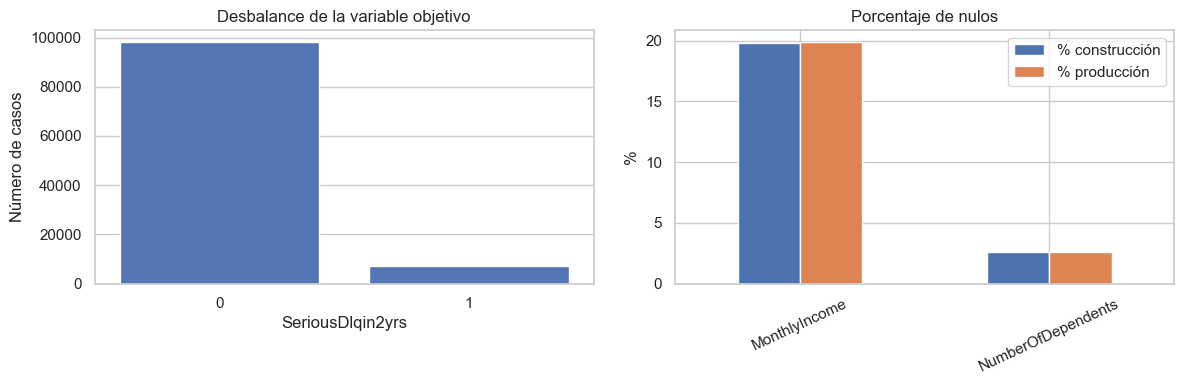

In [3]:
y_completo = construccion[TARGET].astype(int)
X_original = construccion[variables_originales].copy()
X_produccion_original = produccion[variables_originales].copy()

distribucion_target = (
    y_completo.value_counts()
    .sort_index()
    .rename_axis("Clase")
    .to_frame("Casos")
)
distribucion_target["Porcentaje"] = (
    100 * distribucion_target["Casos"] / len(y_completo)
)

nulos = pd.DataFrame(
    {
        "Nulos construcción": construccion.isna().sum(),
        "% construcción": 100 * construccion.isna().mean(),
        "Nulos producción": produccion.isna().sum(),
        "% producción": 100 * produccion.isna().mean(),
    }
)
nulos = nulos[(nulos["Nulos construcción"] > 0) | (nulos["Nulos producción"] > 0)]

columnas_mora = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfTime60-89DaysPastDueNotWorse",
]
anomalias = pd.DataFrame(
    {
        "Comprobación": [
            "Edad igual a 0",
            "Edad mayor de 100",
            "Utilización mayor de 10",
            "DebtRatio mayor de 10",
            "Ingreso mensual igual a 0",
            "Algún contador de mora vale 96/98",
        ],
        "Construcción": [
            int((construccion["age"] == 0).sum()),
            int((construccion["age"] > 100).sum()),
            int((construccion["RevolvingUtilizationOfUnsecuredLines"] > 10).sum()),
            int((construccion["DebtRatio"] > 10).sum()),
            int((construccion["MonthlyIncome"] == 0).sum()),
            int(construccion[columnas_mora].isin([96, 98]).any(axis=1).sum()),
        ],
        "Producción": [
            int((produccion["age"] == 0).sum()),
            int((produccion["age"] > 100).sum()),
            int((produccion["RevolvingUtilizationOfUnsecuredLines"] > 10).sum()),
            int((produccion["DebtRatio"] > 10).sum()),
            int((produccion["MonthlyIncome"] == 0).sum()),
            int(produccion[columnas_mora].isin([96, 98]).any(axis=1).sum()),
        ],
    }
)

comparacion_ks = []
for columna in variables_originales:
    a = construccion[columna].dropna()
    b = produccion[columna].dropna()
    estadistico, pvalor = ks_2samp(a, b)
    comparacion_ks.append(
        {
            "Variable": columna,
            "KS": estadistico,
            "p-valor": pvalor,
            "Media construcción": a.mean(),
            "Media producción": b.mean(),
        }
    )
comparacion_ks = pd.DataFrame(comparacion_ks).sort_values("KS", ascending=False)

hash_construccion = pd.util.hash_pandas_object(X_original, index=False)
hash_produccion = pd.util.hash_pandas_object(X_produccion_original, index=False)
duplicados = pd.Series(
    {
        "Filas duplicadas extra en construcción": int(
            X_original.duplicated().sum()
        ),
        "Filas duplicadas extra en producción": int(
            X_produccion_original.duplicated().sum()
        ),
        "Filas de producción con vector presente en construcción": int(
            hash_produccion.isin(set(hash_construccion)).sum()
        ),
    },
    name="Casos",
).to_frame()

display(distribucion_target)
display(nulos)
display(anomalias)
display(comparacion_ks.head(10))
display(duplicados)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x=y_completo, ax=axes[0], color="#4472C4")
axes[0].set_title("Desbalance de la variable objetivo")
axes[0].set_xlabel("SeriousDlqin2yrs")
axes[0].set_ylabel("Número de casos")

nulos_plot = nulos.drop(index=TARGET, errors="ignore")
nulos_plot[["% construcción", "% producción"]].plot.bar(ax=axes[1])
axes[1].set_title("Porcentaje de nulos")
axes[1].set_ylabel("%")
axes[1].tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

**Lectura del EDA.** La clase positiva es minoritaria, por lo que un modelo que predijera
siempre clase 0 tendría una accuracy elevada pero no resolvería el problema. Los nulos de
ingresos y dependientes aparecen con porcentajes casi iguales en construcción y producción.
Los valores 96/98 de los contadores de mora se consideran códigos especiales: se conserva
su señal mediante un indicador, pero no se interpretan literalmente como 96 o 98 retrasos.
La comparación KS muestra una diferencia univariante pequeña entre ambos conjuntos.

## 4. Preparación reproducible y separación train/validación/test

Se reserva un 15 % como test final intocable. Del 85 % restante se obtiene un 70 % para
entrenar candidatos y un 15 % para seleccionar hiperparámetros y umbrales. La función de
preparación se aplicará sin cambios a validación, test y producción.

No se eliminan las filas con ingresos ausentes. Se añaden indicadores de ausencia, los
códigos 96/98 se convierten en nulos acompañados por un indicador y la única edad inválida
se trata como dato ausente. LightGBM puede trabajar directamente con esos nulos.

In [4]:
def preparar_variables(datos: pd.DataFrame) -> pd.DataFrame:
    X = datos.copy()
    if TARGET in X.columns:
        X = X.drop(columns=TARGET)

    X["MonthlyIncome_missing"] = X["MonthlyIncome"].isna().astype("int8")
    X["NumberOfDependents_missing"] = (
        X["NumberOfDependents"].isna().astype("int8")
    )
    X["DelinquencySentinel96_98"] = (
        X[columnas_mora].isin([96, 98]).any(axis=1).astype("int8")
    )
    X[columnas_mora] = X[columnas_mora].mask(
        X[columnas_mora].isin([96, 98])
    )

    edad_invalida = (X["age"] <= 0) | (X["age"] > 110)
    X["age_invalid"] = edad_invalida.astype("int8")
    X["age"] = X["age"].mask(edad_invalida)
    return X


indices_trainval, indices_test = train_test_split(
    construccion.index,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=y_completo,
)
indices_train, indices_validacion = train_test_split(
    indices_trainval,
    test_size=0.17647058823529413,
    random_state=RANDOM_STATE,
    stratify=y_completo.loc[indices_trainval],
)

X_train_raw = X_original.loc[indices_train].copy()
X_validacion_raw = X_original.loc[indices_validacion].copy()
X_trainval_raw = X_original.loc[indices_trainval].copy()
X_test_raw = X_original.loc[indices_test].copy()

X_train = preparar_variables(X_train_raw)
X_validacion = preparar_variables(X_validacion_raw)
X_trainval = preparar_variables(X_trainval_raw)
X_test = preparar_variables(X_test_raw)
X_produccion = preparar_variables(X_produccion_original)

y_train = y_completo.loc[indices_train]
y_validacion = y_completo.loc[indices_validacion]
y_trainval = y_completo.loc[indices_trainval]
y_test = y_completo.loc[indices_test]

assert X_train.columns.tolist() == X_produccion.columns.tolist()
assert set(indices_train).isdisjoint(indices_validacion)
assert set(indices_trainval).isdisjoint(indices_test)

tabla_particiones = pd.DataFrame(
    {
        "Partición": ["Train", "Validación", "Test"],
        "Filas": [len(X_train), len(X_validacion), len(X_test)],
        "% positivos": [
            100 * y_train.mean(),
            100 * y_validacion.mean(),
            100 * y_test.mean(),
        ],
    }
)
display(tabla_particiones)
print("Variables originales:", len(variables_originales))
print("Variables después de preparar:", X_train.shape[1])
print("Nulos conservados para LightGBM:", int(X_train.isna().sum().sum()))

,Partición,Filas,% positivos
0,Train,73499,6.6831
1,Validación,15751,6.6853
2,Test,15750,6.6857


Variables originales: 10
Variables después de preparar: 14
Nulos conservados para LightGBM: 16762


## 5. Función de coste y pruebas de orientación FP/FN

Con clase positiva igual a mora grave:

- Un **falso positivo** predice riesgo alto para una persona que realmente era clase 0.
- Un **falso negativo** predice riesgo bajo para una persona que realmente era clase 1.

El notebook original invertía estas penalizaciones. Por eso se incluyen pruebas unitarias
simples antes de entrenar: en el escenario 1:10 un FP debe costar 1 y un FN debe costar 10.

In [5]:
def costes_individuales(y_true, y_pred, coste_fp=1.0, coste_fn=1.0):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    return (
        ((y_pred == 1) & (y_true == 0)).astype(float) * coste_fp
        + ((y_pred == 0) & (y_true == 1)).astype(float) * coste_fn
    )


def coste_medio(y_true, y_pred, coste_fp=1.0, coste_fn=1.0):
    return float(costes_individuales(y_true, y_pred, coste_fp, coste_fn).mean())


def optimizar_umbral(y_true, probabilidades, coste_fp=1.0, coste_fn=1.0):
    y_true = np.asarray(y_true, dtype=int)
    probabilidades = np.asarray(probabilidades, dtype=float)
    fpr, tpr, umbrales = roc_curve(y_true, probabilidades)
    n_negativos = (y_true == 0).sum()
    n_positivos = (y_true == 1).sum()
    costes = (
        fpr * n_negativos * coste_fp
        + (1 - tpr) * n_positivos * coste_fn
    ) / len(y_true)
    mejor = int(np.nanargmin(costes))
    return float(umbrales[mejor]), float(costes[mejor])


def metricas_en_umbral(
    y_true, probabilidades, umbral, coste_fp=1.0, coste_fn=1.0
):
    y_true = np.asarray(y_true, dtype=int)
    probabilidades = np.asarray(probabilidades, dtype=float)
    pred = (probabilidades >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "Umbral": float(umbral),
        "Coste medio": coste_medio(y_true, pred, coste_fp, coste_fn),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "Sensibilidad": recall_score(y_true, pred, zero_division=0),
        "Precisión": precision_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "% predicho riesgo": 100 * pred.mean(),
    }


y_prueba = np.array([0, 0, 1, 1])
pred_prueba = np.array([0, 1, 0, 1])
costes_prueba = costes_individuales(
    y_prueba, pred_prueba, coste_fp=1, coste_fn=10
)
assert costes_prueba.tolist() == [0.0, 1.0, 10.0, 0.0]
assert np.isclose(coste_medio(y_prueba, pred_prueba, 1, 10), 2.75)

baselines = []
for nombre, pred in [
    ("Predecir siempre 0", np.zeros(len(y_validacion), dtype=int)),
    ("Predecir siempre 1", np.ones(len(y_validacion), dtype=int)),
]:
    for escenario, c_fp, c_fn in [("1:1", 1, 1), ("1:10", 1, 10)]:
        baselines.append(
            {
                "Política": nombre,
                "Escenario": escenario,
                "Coste medio validación": coste_medio(
                    y_validacion, pred, c_fp, c_fn
                ),
            }
        )
baselines = pd.DataFrame(baselines)
print("Prueba FP/FN superada:", costes_prueba.tolist())
display(baselines)

Prueba FP/FN superada: [0.0, 1.0, 10.0, 0.0]


,Política,Escenario,Coste medio validación
0,Predecir siempre 0,1:1,0.0669
1,Predecir siempre 0,1:10,0.6685
2,Predecir siempre 1,1:1,0.9331
3,Predecir siempre 1,1:10,0.9331


## 6. Comparación de modelos y selección robusta con OOF

Primero se comparan regresión logística, árbol pequeño y LightGBM sobre la partición de
validación para comprobar que el modelo no lineal aporta valor. Después se comparan los
dos finalistas mediante validación estratificada sobre train más validación. El finalista con early stopping se estabiliza con tres repeticiones de cinco folds:

- LightGBM conservador de 7 hojas y número fijo de árboles.
- LightGBM de 15 hojas con hasta 2.000 árboles y early stopping de 100 rondas.

Cada observación recibe tres probabilidades out-of-fold producidas por modelos que no la han visto; se promedian. Los umbrales definitivos minimizan el coste sobre las probabilidades OOF promediadas; la mediana y dispersión de los 15 folds se conservan como diagnóstico. El número de árboles es la mediana de las 15 paradas tempranas. El
test continúa completamente aislado durante todo el proceso.

In [6]:
def crear_lightgbm_fijo(
    num_leaves=7,
    n_estimators=300,
    learning_rate=0.04,
    min_child_samples=200,
    random_state=RANDOM_STATE,
):
    return LGBMClassifier(
        objective="binary",
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        num_leaves=num_leaves,
        min_child_samples=min_child_samples,
        subsample=0.9,
        subsample_freq=1,
        colsample_bytree=0.9,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=random_state,
        n_jobs=-1,
        verbosity=-1,
    )


def crear_lightgbm_early(
    n_estimators=2_000,
    random_state=RANDOM_STATE,
):
    return LGBMClassifier(
        objective="binary",
        n_estimators=n_estimators,
        learning_rate=0.02,
        num_leaves=15,
        min_child_samples=200,
        subsample=0.9,
        subsample_freq=1,
        colsample_bytree=0.9,
        reg_alpha=0.1,
        reg_lambda=2.0,
        random_state=random_state,
        n_jobs=-1,
        verbosity=-1,
    )


modelos_exploratorios = {
    "Regresión logística": Pipeline(
        [
            ("imputación", SimpleImputer(strategy="median")),
            ("escalado", StandardScaler()),
            (
                "modelo",
                LogisticRegression(max_iter=2_000, random_state=RANDOM_STATE),
            ),
        ]
    ),
    "Árbol pequeño": Pipeline(
        [
            ("imputación", SimpleImputer(strategy="median")),
            (
                "modelo",
                DecisionTreeClassifier(
                    max_leaf_nodes=12,
                    min_samples_leaf=200,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "LightGBM conservador (7 hojas)": crear_lightgbm_fijo(),
}

filas_exploratorias = []
for nombre, estimador in modelos_exploratorios.items():
    modelo = clone(estimador)
    modelo.fit(X_train, y_train)
    p_val = modelo.predict_proba(X_validacion)[:, 1]
    umbral_11_candidato, coste_11 = optimizar_umbral(
        y_validacion, p_val, 1, 1
    )
    umbral_110_candidato, coste_110 = optimizar_umbral(
        y_validacion, p_val, 1, 10
    )
    filas_exploratorias.append(
        {
            "Modelo": nombre,
            "ROC-AUC": roc_auc_score(y_validacion, p_val),
            "PR-AUC": average_precision_score(y_validacion, p_val),
            "Brier": brier_score_loss(y_validacion, p_val),
            "Coste 1:1": coste_11,
            "Coste 1:10": coste_110,
        }
    )

comparacion_exploratoria = (
    pd.DataFrame(filas_exploratorias)
    .sort_values("Coste 1:10")
    .reset_index(drop=True)
)
display(comparacion_exploratoria)

X_cv_desarrollo = X_trainval.reset_index(drop=True)
y_cv_desarrollo = y_trainval.reset_index(drop=True)
cv_desarrollo = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=RANDOM_STATE
)


def predicciones_oof_finalista(tipo):
    if tipo == "L7 fijo":
        repeticiones = 1
    elif tipo == "L15 early stopping":
        repeticiones = 3
    else:
        raise ValueError(tipo)

    suma_probabilidades = np.zeros(len(y_cv_desarrollo), dtype=float)
    numero_predicciones = np.zeros(len(y_cv_desarrollo), dtype=int)
    mejores_iteraciones = []
    umbrales_fold_11 = []
    umbrales_fold_110 = []

    for repeticion in range(repeticiones):
        cv_repeticion = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=RANDOM_STATE + repeticion,
        )
        for fold, (idx_fit, idx_val) in enumerate(
            cv_repeticion.split(X_cv_desarrollo, y_cv_desarrollo)
        ):
            semilla_modelo = RANDOM_STATE + 100 * repeticion + fold
            if tipo == "L7 fijo":
                modelo = crear_lightgbm_fijo(
                    random_state=semilla_modelo
                )
                modelo.fit(
                    X_cv_desarrollo.iloc[idx_fit],
                    y_cv_desarrollo.iloc[idx_fit],
                )
            else:
                modelo = crear_lightgbm_early(
                    n_estimators=2_000,
                    random_state=semilla_modelo,
                )
                modelo.fit(
                    X_cv_desarrollo.iloc[idx_fit],
                    y_cv_desarrollo.iloc[idx_fit],
                    eval_set=[
                        (
                            X_cv_desarrollo.iloc[idx_val],
                            y_cv_desarrollo.iloc[idx_val],
                        )
                    ],
                    eval_metric="binary_logloss",
                    callbacks=[
                        lightgbm.early_stopping(100, verbose=False)
                    ],
                )
                mejores_iteraciones.append(modelo.best_iteration_)

            p_fold = modelo.predict_proba(
                X_cv_desarrollo.iloc[idx_val]
            )[:, 1]
            suma_probabilidades[idx_val] += p_fold
            numero_predicciones[idx_val] += 1
            umbral_fold_11, _ = optimizar_umbral(
                y_cv_desarrollo.iloc[idx_val], p_fold, 1, 1
            )
            umbral_fold_110, _ = optimizar_umbral(
                y_cv_desarrollo.iloc[idx_val], p_fold, 1, 10
            )
            umbrales_fold_11.append(umbral_fold_11)
            umbrales_fold_110.append(umbral_fold_110)

    assert (numero_predicciones == repeticiones).all()
    probabilidades = suma_probabilidades / numero_predicciones
    return (
        probabilidades,
        mejores_iteraciones,
        umbrales_fold_11,
        umbrales_fold_110,
    )


p_oof_l7, _, _, _ = predicciones_oof_finalista("L7 fijo")
(
    p_oof_early,
    iteraciones_cv_evaluacion,
    umbrales_fold_11_evaluacion,
    umbrales_fold_110_evaluacion,
) = predicciones_oof_finalista("L15 early stopping")

filas_oof = []
for nombre, probabilidades in [
    ("LightGBM 7 hojas fijo", p_oof_l7),
    ("LightGBM 15 hojas + early stopping", p_oof_early),
]:
    umbral_11_candidato, coste_11 = optimizar_umbral(
        y_cv_desarrollo, probabilidades, 1, 1
    )
    umbral_110_candidato, coste_110 = optimizar_umbral(
        y_cv_desarrollo, probabilidades, 1, 10
    )
    filas_oof.append(
        {
            "Modelo": nombre,
            "ROC-AUC OOF": roc_auc_score(
                y_cv_desarrollo, probabilidades
            ),
            "PR-AUC OOF": average_precision_score(
                y_cv_desarrollo, probabilidades
            ),
            "Brier OOF": brier_score_loss(
                y_cv_desarrollo, probabilidades
            ),
            "Umbral OOF 1:1": umbral_11_candidato,
            "Coste OOF 1:1": coste_11,
            "Umbral OOF 1:10": umbral_110_candidato,
            "Coste OOF 1:10": coste_110,
        }
    )

comparacion_oof = (
    pd.DataFrame(filas_oof)
    .sort_values(["Coste OOF 1:10", "Coste OOF 1:1"])
    .reset_index(drop=True)
)
assert comparacion_oof.loc[0, "Modelo"] == (
    "LightGBM 15 hojas + early stopping"
)

nombre_modelo = comparacion_oof.loc[0, "Modelo"]
p_oof_evaluacion = p_oof_early
umbral_11, _ = optimizar_umbral(
    y_cv_desarrollo, p_oof_evaluacion, 1, 1
)
umbral_110, _ = optimizar_umbral(
    y_cv_desarrollo, p_oof_evaluacion, 1, 10
)
n_estimators_evaluacion = int(np.median(iteraciones_cv_evaluacion))
modelo_evaluacion_config = crear_lightgbm_early(
    n_estimators=n_estimators_evaluacion,
    random_state=RANDOM_STATE,
)

estabilidad_umbrales_evaluacion = pd.DataFrame(
    {
        "Escenario": ["1:1", "1:10"],
        "Umbral global OOF elegido": [umbral_11, umbral_110],
        "Mediana por fold": [
            np.median(umbrales_fold_11_evaluacion),
            np.median(umbrales_fold_110_evaluacion),
        ],
        "Media": [
            np.mean(umbrales_fold_11_evaluacion),
            np.mean(umbrales_fold_110_evaluacion),
        ],
        "Desviación": [
            np.std(umbrales_fold_11_evaluacion),
            np.std(umbrales_fold_110_evaluacion),
        ],
        "Número de folds": [
            len(umbrales_fold_11_evaluacion),
            len(umbrales_fold_110_evaluacion),
        ],
    }
)
assert len(iteraciones_cv_evaluacion) == 15
assert umbral_110 < umbral_11
display(comparacion_oof)
display(estabilidad_umbrales_evaluacion)
print("Modelo seleccionado:", nombre_modelo)
print("Mejores iteraciones por fold:", iteraciones_cv_evaluacion)
print("Número de árboles para evaluación:", n_estimators_evaluacion)
print(f"Umbral OOF de evaluación 1:1  = {umbral_11:.6f}")
print(f"Umbral OOF de evaluación 1:10 = {umbral_110:.6f}")

,Modelo,ROC-AUC,PR-AUC,Brier,Coste 1:1,Coste 1:10
0,LightGBM conservador (7 hojas),0.8736,0.4149,0.0484,0.0620,0.3148
1,Árbol pequeño,0.8329,0.3326,0.0503,0.0645,0.3472
2,Regresión logística,0.8303,0.3654,0.0522,0.0636,0.3548


,Modelo,ROC-AUC OOF,PR-AUC OOF,Brier OOF,Umbral OOF 1:1,Coste OOF 1:1,Umbral OOF 1:10,Coste OOF 1:10
0,LightGBM 15 hojas + early stopping,0.8655,0.4046,0.0488,0.5380,0.0617,0.0907,0.3314
1,LightGBM 7 hojas fijo,0.8648,0.4043,0.0488,0.5447,0.0619,0.0885,0.3322


,Escenario,Umbral global OOF elegido,Mediana por fold,Media,Desviación,Número de folds
0,1:1,0.5380,0.5013,0.5101,0.0230,15
1,1:10,0.0907,0.0944,0.0920,0.0126,15


Modelo seleccionado: LightGBM 15 hojas + early stopping
Mejores iteraciones por fold: [449, 299, 501, 483, 391, 347, 465, 451, 507, 309, 351, 411, 423, 418, 410]
Número de árboles para evaluación: 418
Umbral OOF de evaluación 1:1  = 0.537964
Umbral OOF de evaluación 1:10 = 0.090730


**Interpretación de la selección.** El modelo ganador debe mejorar simultáneamente la
discriminación y el coste. Un umbral menor en 1:10 es obligatorio desde el punto de vista
de negocio: al encarecer el falso negativo se marcan más solicitudes como riesgo alto.
La regresión y el árbol sirven de referencias comprensibles, pero no gobiernan la entrega
si su coste es peor.

## 7. Calibración y curvas de coste OOF

La fórmula teórica predice umbrales de 0,5 para 1:1 y 1/11 para 1:10 cuando las
probabilidades están calibradas. Se contrastan esos valores con los mínimos globales obtenidos a
partir de las predicciones OOF promediadas de tres repeticiones de cinco folds.

Al no proceder de una única validación, estas probabilidades permiten estimar umbrales más
estables y reducen el riesgo de adaptar la política a una partición afortunada.

,Escenario,Umbral teórico,Umbral OOF evaluación,Diferencia absoluta
0,1:1,0.5000,0.5380,0.0380
1,1:10,0.0909,0.0907,0.0002


Brier OOF de desarrollo: 0.048759


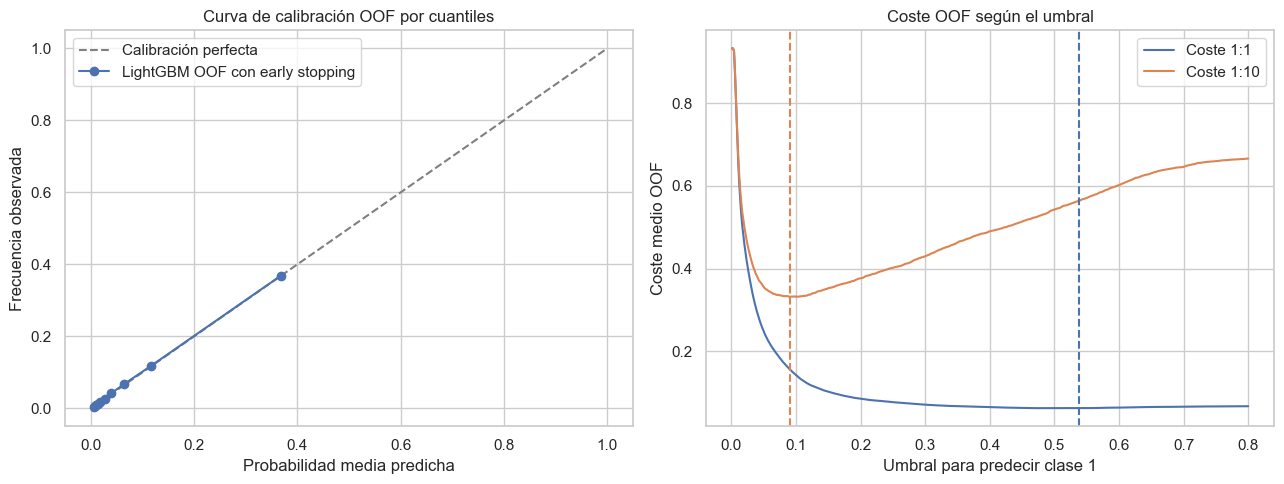

In [7]:
fraccion_positivos, media_predicha = calibration_curve(
    y_cv_desarrollo,
    p_oof_evaluacion,
    n_bins=10,
    strategy="quantile",
)

umbrales_grafico = np.linspace(0.001, 0.80, 500)
costes_11_grafico = [
    coste_medio(y_cv_desarrollo, p_oof_evaluacion >= u, 1, 1)
    for u in umbrales_grafico
]
costes_110_grafico = [
    coste_medio(y_cv_desarrollo, p_oof_evaluacion >= u, 1, 10)
    for u in umbrales_grafico
]

comparacion_umbrales = pd.DataFrame(
    {
        "Escenario": ["1:1", "1:10"],
        "Umbral teórico": [0.5, 1 / 11],
        "Umbral OOF evaluación": [umbral_11, umbral_110],
        "Diferencia absoluta": [
            abs(umbral_11 - 0.5),
            abs(umbral_110 - 1 / 11),
        ],
    }
)
display(comparacion_umbrales)
print(
    "Brier OOF de desarrollo:",
    f"{brier_score_loss(y_cv_desarrollo, p_oof_evaluacion):.6f}",
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(
    [0, 1], [0, 1], "--", color="grey", label="Calibración perfecta"
)
axes[0].plot(
    media_predicha,
    fraccion_positivos,
    "o-",
    label="LightGBM OOF con early stopping",
)
axes[0].set_xlabel("Probabilidad media predicha")
axes[0].set_ylabel("Frecuencia observada")
axes[0].set_title("Curva de calibración OOF por cuantiles")
axes[0].legend()

axes[1].plot(umbrales_grafico, costes_11_grafico, label="Coste 1:1")
axes[1].plot(umbrales_grafico, costes_110_grafico, label="Coste 1:10")
axes[1].axvline(umbral_11, color="C0", linestyle="--")
axes[1].axvline(umbral_110, color="C1", linestyle="--")
axes[1].set_xlabel("Umbral para predecir clase 1")
axes[1].set_ylabel("Coste medio OOF")
axes[1].set_title("Coste OOF según el umbral")
axes[1].legend()
plt.tight_layout()
plt.show()

## 8. Evaluación final en el test intacto

Tras bloquear arquitectura, número de árboles y umbrales con OOF, se reentrena el modelo
con train más validación. El test se utiliza una sola vez para estimar el comportamiento
fuera de muestra. No se reoptimiza ninguna decisión con sus etiquetas.

,Umbral,Coste medio,TN,FP,FN,TP,Sensibilidad,Precisión,F1,% predicho riesgo,ROC-AUC,PR-AUC,Brier,Baseline siempre 0
Escenario,,,,,,,,,,,,,,
1:1,0.5380,0.0636,14587,110,891,162,0.1538,0.5956,0.2445,1.7270,0.8720,0.4027,0.0490,0.0669
1:10,0.0907,0.3224,12529,2168,291,762,0.7236,0.2601,0.3826,18.6032,0.8720,0.4027,0.0490,0.6686


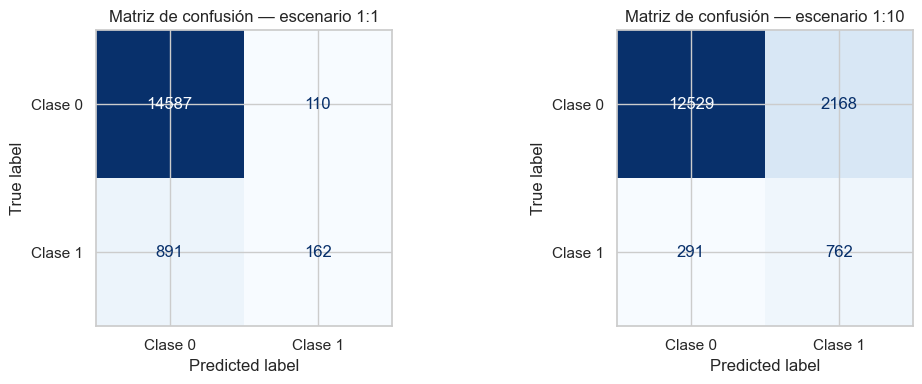

In [8]:
modelo_evaluacion = clone(modelo_evaluacion_config)
modelo_evaluacion.fit(X_trainval, y_trainval)
p_test_evaluacion = modelo_evaluacion.predict_proba(X_test)[:, 1]

resultados_test = []
for escenario, umbral, c_fp, c_fn in [
    ("1:1", umbral_11, 1, 1),
    ("1:10", umbral_110, 1, 10),
]:
    fila = metricas_en_umbral(
        y_test, p_test_evaluacion, umbral, c_fp, c_fn
    )
    fila["Escenario"] = escenario
    fila["ROC-AUC"] = roc_auc_score(y_test, p_test_evaluacion)
    fila["PR-AUC"] = average_precision_score(
        y_test, p_test_evaluacion
    )
    fila["Brier"] = brier_score_loss(y_test, p_test_evaluacion)
    fila["Baseline siempre 0"] = c_fn * y_test.mean()
    resultados_test.append(fila)

resultados_test = pd.DataFrame(resultados_test).set_index("Escenario")
pred_test_11_evaluacion = (
    p_test_evaluacion >= umbral_11
).astype(int)
pred_test_110_evaluacion = (
    p_test_evaluacion >= umbral_110
).astype(int)

assert resultados_test.loc["1:1", "Coste medio"] < resultados_test.loc[
    "1:1", "Baseline siempre 0"
]
assert resultados_test.loc["1:10", "Coste medio"] < resultados_test.loc[
    "1:10", "Baseline siempre 0"
]
assert pred_test_110_evaluacion.mean() > pred_test_11_evaluacion.mean()

display(resultados_test)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, escenario, pred in [
    (axes[0], "1:1", pred_test_11_evaluacion),
    (axes[1], "1:10", pred_test_110_evaluacion),
]:
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        pred,
        labels=[0, 1],
        display_labels=["Clase 0", "Clase 1"],
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )
    ax.set_title(f"Matriz de confusión — escenario {escenario}")
plt.tight_layout()
plt.show()

# Copias explícitas para las auditorías que deben conservar carácter
# estrictamente fuera de muestra.
umbral_11_evaluacion = umbral_11
umbral_110_evaluacion = umbral_110

La siguiente celda traduce automáticamente las métricas ejecutadas. Al generarse desde
las variables del notebook no puede quedar desincronizada tras una nueva ejecución.

In [9]:
fila_11 = resultados_test.loc["1:1"]
fila_110 = resultados_test.loc["1:10"]
display(
    Markdown(
        f'''
        **Lectura del test.** El modelo obtiene ROC-AUC **{fila_11['ROC-AUC']:.3f}**
        y PR-AUC **{fila_11['PR-AUC']:.3f}**. En 1:1 el coste medio es
        **{fila_11['Coste medio']:.4f}**, frente a **{fila_11['Baseline siempre 0']:.4f}**
        del baseline. En 1:10 baja de **{fila_110['Baseline siempre 0']:.4f}** a
        **{fila_110['Coste medio']:.4f}**. La política 1:10 predice riesgo alto en
        **{fila_110['% predicho riesgo']:.2f} %** de los casos, frente a
        **{fila_11['% predicho riesgo']:.2f} %** en 1:1. El comportamiento es coherente:
        al ser diez veces más caro no detectar una mora, aumenta la sensibilidad aunque
        también aumenten los falsos positivos.
        '''
    )
)


        **Lectura del test.** El modelo obtiene ROC-AUC **0.872**
        y PR-AUC **0.403**. En 1:1 el coste medio es
        **0.0636**, frente a **0.0669**
        del baseline. En 1:10 baja de **0.6686** a
        **0.3224**. La política 1:10 predice riesgo alto en
        **18.60 %** de los casos, frente a
        **1.73 %** en 1:1. El comportamiento es coherente:
        al ser diez veces más caro no detectar una mora, aumenta la sensibilidad aunque
        también aumenten los falsos positivos.
        

## 9. Validación OOF completa y modelo de producción

Una vez finalizada la evaluación honesta, se repite el protocolo de tres repeticiones de cinco folds con
las 105.000 etiquetas de construcción. Esto permite:

1. obtener tres probabilidades OOF por observación y elegir los umbrales que minimizan el coste global sobre su promedio;
2. estimar un número robusto de árboles mediante early stopping;
3. reentrenar el modelo de producción con las 105.000 filas.

Las métricas del apartado anterior siguen siendo la estimación fuera de muestra. Este
nuevo modelo se utiliza exclusivamente para producción y para explicar la política
finalmente entregada.

In [10]:
X_completo_preparado = preparar_variables(X_original)
y_completo_cv = y_completo.reset_index(drop=True)
X_completo_cv = X_completo_preparado.reset_index(drop=True)

suma_oof_produccion = np.zeros(len(y_completo_cv), dtype=float)
conteo_oof_produccion = np.zeros(len(y_completo_cv), dtype=int)
iteraciones_cv_produccion = []
umbrales_fold_11_produccion = []
umbrales_fold_110_produccion = []

for repeticion in range(3):
    cv_produccion = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE + repeticion,
    )
    for fold, (idx_fit, idx_val) in enumerate(
        cv_produccion.split(X_completo_cv, y_completo_cv)
    ):
        semilla_modelo = RANDOM_STATE + 100 * repeticion + fold
        modelo_fold = crear_lightgbm_early(
            n_estimators=2_000,
            random_state=semilla_modelo,
        )
        modelo_fold.fit(
            X_completo_cv.iloc[idx_fit],
            y_completo_cv.iloc[idx_fit],
            eval_set=[
                (
                    X_completo_cv.iloc[idx_val],
                    y_completo_cv.iloc[idx_val],
                )
            ],
            eval_metric="binary_logloss",
            callbacks=[
                lightgbm.early_stopping(100, verbose=False)
            ],
        )
        iteraciones_cv_produccion.append(modelo_fold.best_iteration_)
        p_fold = modelo_fold.predict_proba(
            X_completo_cv.iloc[idx_val]
        )[:, 1]
        suma_oof_produccion[idx_val] += p_fold
        conteo_oof_produccion[idx_val] += 1
        umbral_fold_11, _ = optimizar_umbral(
            y_completo_cv.iloc[idx_val], p_fold, 1, 1
        )
        umbral_fold_110, _ = optimizar_umbral(
            y_completo_cv.iloc[idx_val], p_fold, 1, 10
        )
        umbrales_fold_11_produccion.append(umbral_fold_11)
        umbrales_fold_110_produccion.append(umbral_fold_110)

assert (conteo_oof_produccion == 3).all()
p_oof_produccion = suma_oof_produccion / conteo_oof_produccion

umbral_11_produccion, coste_oof_11 = optimizar_umbral(
    y_completo_cv, p_oof_produccion, 1, 1
)
umbral_110_produccion, coste_oof_110 = optimizar_umbral(
    y_completo_cv, p_oof_produccion, 1, 10
)
n_estimators_produccion = int(np.median(iteraciones_cv_produccion))

modelo_produccion = crear_lightgbm_early(
    n_estimators=n_estimators_produccion,
    random_state=RANDOM_STATE,
)
modelo_produccion.fit(X_completo_preparado, y_completo)

resumen_oof_produccion = pd.DataFrame(
    {
        "ROC-AUC OOF": [
            roc_auc_score(y_completo_cv, p_oof_produccion)
        ],
        "PR-AUC OOF": [
            average_precision_score(
                y_completo_cv, p_oof_produccion
            )
        ],
        "Brier OOF": [
            brier_score_loss(y_completo_cv, p_oof_produccion)
        ],
        "Umbral 1:1": [umbral_11_produccion],
        "Mediana folds 1:1": [
            np.median(umbrales_fold_11_produccion)
        ],
        "Coste OOF 1:1": [coste_oof_11],
        "Umbral 1:10": [umbral_110_produccion],
        "Mediana folds 1:10": [
            np.median(umbrales_fold_110_produccion)
        ],
        "Coste OOF 1:10": [coste_oof_110],
        "Árboles finales": [n_estimators_produccion],
        "Folds repetidos": [len(iteraciones_cv_produccion)],
    },
    index=["Modelo de producción"],
)
display(resumen_oof_produccion)
print(
    "Mejores iteraciones en los quince ajustes OOF:",
    iteraciones_cv_produccion,
)
print(
    "Filas usadas para el modelo de evaluación:",
    len(X_trainval),
)
print(
    "Filas usadas para el modelo de producción:",
    len(X_completo_preparado),
)

# A partir de aquí, modelo_final representa exactamente el modelo que
# genera los dos CSV y que se audita con SHAP y contrafactuales.
modelo_final = modelo_produccion
nombre_modelo = "LightGBM 15 hojas + early stopping OOF"
umbral_11 = umbral_11_produccion
umbral_110 = umbral_110_produccion
p_test = modelo_final.predict_proba(X_test)[:, 1]
pred_test_11 = (p_test >= umbral_11).astype(int)
pred_test_110 = (p_test >= umbral_110).astype(int)

p_test_evaluacion_serie = pd.Series(
    p_test_evaluacion, index=indices_test
)
pred_test_110_evaluacion_serie = pd.Series(
    pred_test_110_evaluacion, index=indices_test
)

assert len(iteraciones_cv_produccion) == 15
assert len(X_completo_preparado) == 105_000
assert umbral_110 < umbral_11

,ROC-AUC OOF,PR-AUC OOF,Brier OOF,Umbral 1:1,Mediana folds 1:1,Coste OOF 1:1,Umbral 1:10,Mediana folds 1:10,Coste OOF 1:10,Árboles finales,Folds repetidos
Modelo de producción,0.8668,0.4046,0.0488,0.5226,0.5221,0.0621,0.0815,0.0859,0.3296,455,15


Mejores iteraciones en los quince ajustes OOF: [500, 409, 439, 370, 462, 360, 409, 475, 455, 541, 394, 564, 550, 400, 463]
Filas usadas para el modelo de evaluación: 89250
Filas usadas para el modelo de producción: 105000


## 10. Predicción de producción y generación de los entregables

Se aplica exactamente la misma preparación y el mismo modelo a las 45.000 filas de
producción. Solo cambia el umbral OOF asociado a cada escenario. Los CSV conservan todas las columnas y el orden
original; únicamente se rellena **SeriousDlqin2yrs** con 0/1. Se escriben sin índice y se
vuelven a leer para validar el contrato de entrega.

In [ ]:
p_produccion = modelo_final.predict_proba(X_produccion)[:, 1]
pred_produccion_11 = (p_produccion >= umbral_11).astype(int)
pred_produccion_110 = (p_produccion >= umbral_110).astype(int)

salida_11 = produccion.copy()
salida_110 = produccion.copy()
salida_11[TARGET] = pd.Series(
    pred_produccion_11, index=salida_11.index, dtype="int64"
)
salida_110[TARGET] = pd.Series(
    pred_produccion_110, index=salida_110.index, dtype="int64"
)

ruta_salida_11 = ruta_base / "javi/cs_produccion1.csv"
ruta_salida_110 = ruta_base / "javi/cs_produccion2.csv"
salida_11.to_csv(ruta_salida_11, index=False)
salida_110.to_csv(ruta_salida_110, index=False)

assert salida_11.shape == produccion.shape == (45_000, 11)
assert salida_110.shape == produccion.shape
assert salida_11.columns.tolist() == columnas_originales
assert salida_110.columns.tolist() == columnas_originales
pd.testing.assert_frame_equal(
    salida_11[variables_originales],
    produccion[variables_originales],
    check_dtype=True,
)
pd.testing.assert_frame_equal(
    salida_110[variables_originales],
    produccion[variables_originales],
    check_dtype=True,
)
assert set(salida_11[TARGET].unique()).issubset({0, 1})
assert set(salida_110[TARGET].unique()).issubset({0, 1})

recarga_11 = pd.read_csv(ruta_salida_11)
recarga_110 = pd.read_csv(ruta_salida_110)
assert recarga_11.shape == (45_000, 11)
assert recarga_110.shape == (45_000, 11)
assert recarga_11[TARGET].isna().sum() == 0
assert recarga_110[TARGET].isna().sum() == 0

resumen_csv = pd.DataFrame(
    {
        "Fichero": [ruta_salida_11.name, ruta_salida_110.name],
        "Filas": [len(salida_11), len(salida_110)],
        "Umbral": [umbral_11, umbral_110],
        "Predicciones clase 1": [
            int(pred_produccion_11.sum()),
            int(pred_produccion_110.sum()),
        ],
        "% clase 1": [
            100 * pred_produccion_11.mean(),
            100 * pred_produccion_110.mean(),
        ],
    }
)
display(resumen_csv)
display(salida_11.head())

,Fichero,Filas,Umbral,Predicciones clase 1,% clase 1
0,cs_produccion1.csv,45000,0.5226,840,1.8667
1,cs_produccion2.csv,45000,0.0815,9157,20.3489


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1.0000,30,0,0.1851,"1,706.0000",0,4,0,0,3.0000
1,0,1.0000,46,0,0.0000,0.0000,0,2,0,0,3.0000
2,0,0.0404,37,0,"1,831.0000",NaN,5,0,1,0,0.0000
3,0,0.6199,75,0,0.2997,"4,583.0000",14,0,0,0,0.0000
4,0,0.0214,58,0,0.5518,"4,200.0000",30,0,1,0,1.0000


## 11. SHAP global: qué variables gobiernan el riesgo

SHAP descompone cada probabilidad en un valor base más contribuciones por variable. Se
explica una muestra reproducible de producción con salida en espacio de probabilidad. El
gráfico de barras ordena la magnitud media absoluta; el beeswarm añade dirección y
dispersión.

El background procede de las 105.000 filas de construcción y se valida numéricamente que
valor base más SHAP reproduce la probabilidad del modelo final de producción.

Error máximo de aditividad SHAP: 3.93e-08


,Variable,Media |SHAP|
0,RevolvingUtilizationOfUnsecuredLines,0.0303
1,NumberOfTimes90DaysLate,0.0274
2,NumberOfTime30-59DaysPastDueNotWorse,0.0199
3,NumberOfTime60-89DaysPastDueNotWorse,0.0128
4,age,0.0097
5,NumberOfOpenCreditLinesAndLoans,0.0068
6,DebtRatio,0.0056
7,MonthlyIncome,0.0045
8,NumberRealEstateLoansOrLines,0.0037
9,NumberOfDependents,0.0013


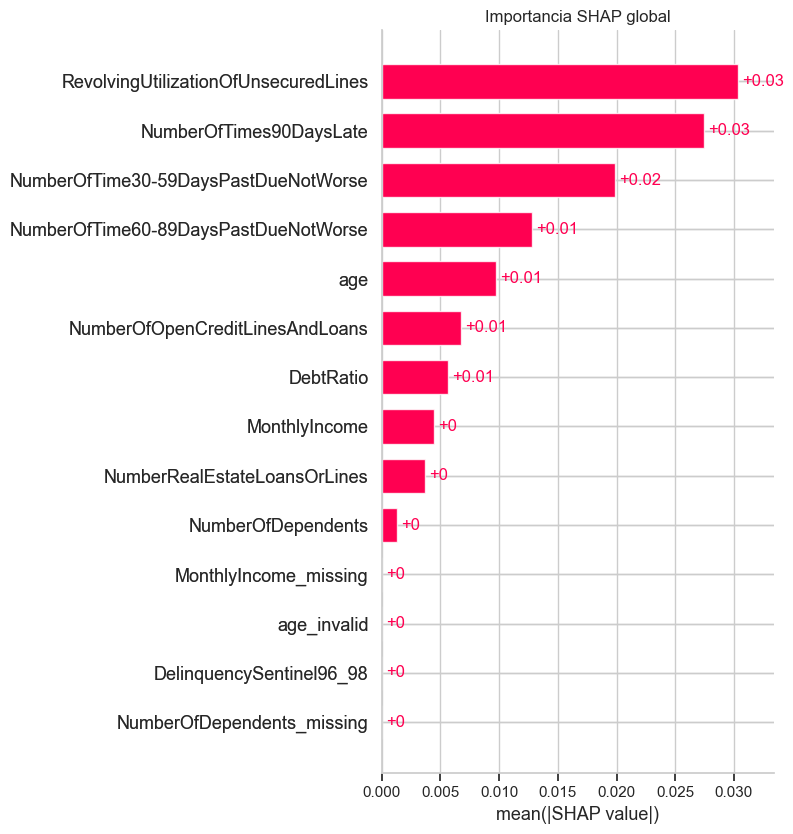

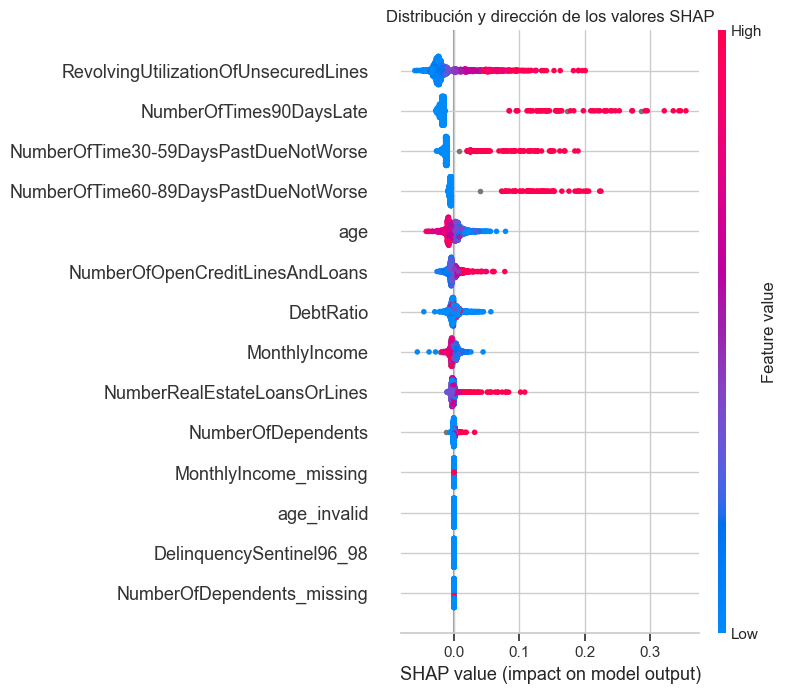

In [ ]:
background_shap = X_completo_preparado.sample(n=100, random_state=RANDOM_STATE)
X_shap_global = X_produccion.sample(
    n=min(1_200, len(X_produccion)), random_state=RANDOM_STATE
)

explicador_shap = shap.TreeExplainer(
    modelo_final,
    data=background_shap,
    feature_perturbation="interventional",
    model_output="probability",
)
valores_shap_global = explicador_shap(
    X_shap_global, check_additivity=False
)
reconstruccion = (
    np.asarray(valores_shap_global.base_values)
    + valores_shap_global.values.sum(axis=1)
)
error_aditividad_shap = float(
    np.max(
        np.abs(
            reconstruccion - modelo_final.predict_proba(X_shap_global)[:, 1]
        )
    )
)
assert error_aditividad_shap < 1e-5

importancia_shap = (
    pd.DataFrame(
        {
            "Variable": X_shap_global.columns,
            "Media |SHAP|": np.abs(valores_shap_global.values).mean(axis=0),
        }
    )
    .sort_values("Media |SHAP|", ascending=False)
    .reset_index(drop=True)
)
print("Error máximo de aditividad SHAP:", f"{error_aditividad_shap:.2e}")
display(importancia_shap)

shap.plots.bar(valores_shap_global, max_display=14, show=False)
plt.title("Importancia SHAP global")
plt.tight_layout()
plt.show()

shap.plots.beeswarm(valores_shap_global, max_display=14, show=False)
plt.title("Distribución y dirección de los valores SHAP")
plt.tight_layout()
plt.show()

Esta interpretación se genera con el ranking real obtenido. Una contribución SHAP positiva
aumenta la probabilidad de clase 1; una negativa la reduce. La magnitud global no implica
causalidad y puede repartirse entre variables correlacionadas.

In [13]:
principales_shap = importancia_shap.head(5)["Variable"].tolist()
display(
    Markdown(
        "**Resultado global.** Las cinco variables con mayor contribución media absoluta "
        "son: " + ", ".join(f"**{v}**" for v in principales_shap) + "."
    )
)

**Resultado global.** Las cinco variables con mayor contribución media absoluta son: **RevolvingUtilizationOfUnsecuredLines**, **NumberOfTimes90DaysLate**, **NumberOfTime30-59DaysPastDueNotWorse**, **NumberOfTime60-89DaysPastDueNotWorse**, **age**.

## 12. SHAP local: por qué se decide en casos concretos

Se explican un verdadero negativo, verdadero positivo, falso positivo y falso negativo
del **test fuera de muestra** del apartado 8, además de un caso cuya decisión cambia
entre 1:1 y 1:10. Para ello se usa exclusivamente el `modelo_evaluacion`, entrenado con
train más validación sin haber visto las etiquetas del test.

Los cuatro casos de confusión se eligen cerca del umbral de evaluación 1:10 para estudiar
la frontera de decisión. El quinto muestra el efecto de cambiar solo la política de coste.
Los waterfall se calculan con un explicador SHAP separado para el modelo de evaluación;
el SHAP global del apartado anterior continúa explicando el modelo final de producción.

,Caso,Índice original,Clase real,Probabilidad,Umbral 1:10,Predicción 1:1,Predicción 1:10
0,Verdadero negativo 1:10,20118,0,0.0907,0.0907,0,0
1,Verdadero positivo 1:10,66854,1,0.0909,0.0907,0,1
2,Falso positivo 1:10,60989,0,0.0908,0.0907,0,1
3,Falso negativo 1:10,13793,1,0.0902,0.0907,0,0
4,Cambio de política 1:1 → 1:10,99854,0,0.3142,0.0907,0,1


,Caso,Variable,Valor,SHAP,Dirección
0,Verdadero negativo 1:10,RevolvingUtilizationOfUnsecuredLines,1.0000,0.0548,sube riesgo
1,Verdadero negativo 1:10,age,38.0000,0.0177,sube riesgo
2,Verdadero negativo 1:10,NumberOfTimes90DaysLate,0.0000,-0.0159,baja riesgo
3,Verdadero positivo 1:10,NumberOfTime30-59DaysPastDueNotWorse,3.0000,0.0956,sube riesgo
4,Verdadero positivo 1:10,RevolvingUtilizationOfUnsecuredLines,0.0066,-0.0467,baja riesgo
5,Verdadero positivo 1:10,NumberOfTimes90DaysLate,0.0000,-0.0154,baja riesgo
6,Falso positivo 1:10,NumberOfTime30-59DaysPastDueNotWorse,2.0000,0.0614,sube riesgo
7,Falso positivo 1:10,NumberOfOpenCreditLinesAndLoans,19.0000,0.0150,sube riesgo
8,Falso positivo 1:10,MonthlyIncome,"12,990.0000",-0.0149,baja riesgo
9,Falso negativo 1:10,RevolvingUtilizationOfUnsecuredLines,0.8725,0.0502,sube riesgo


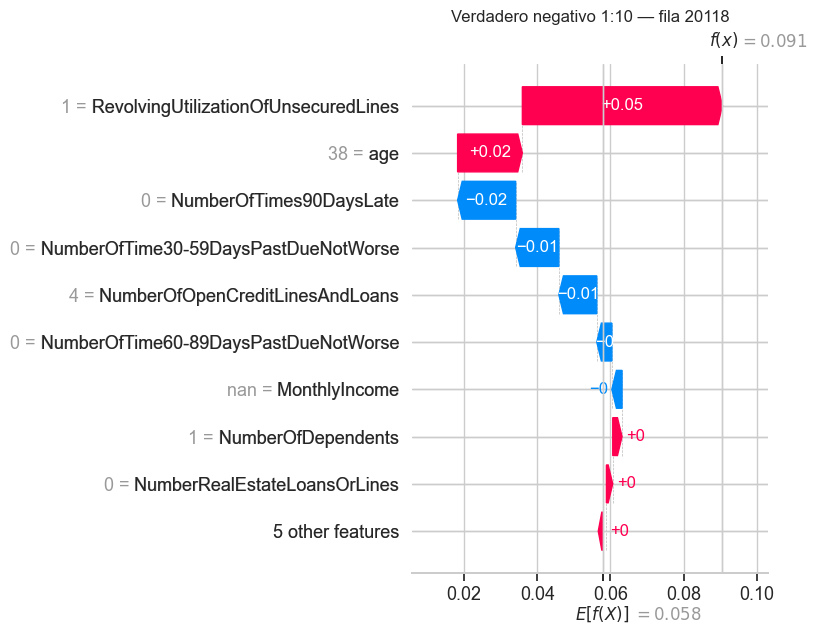

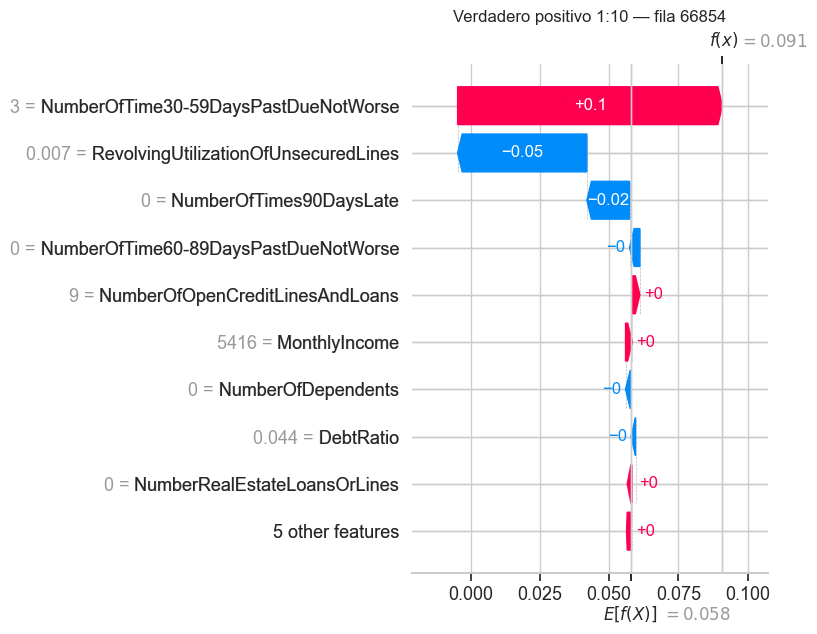

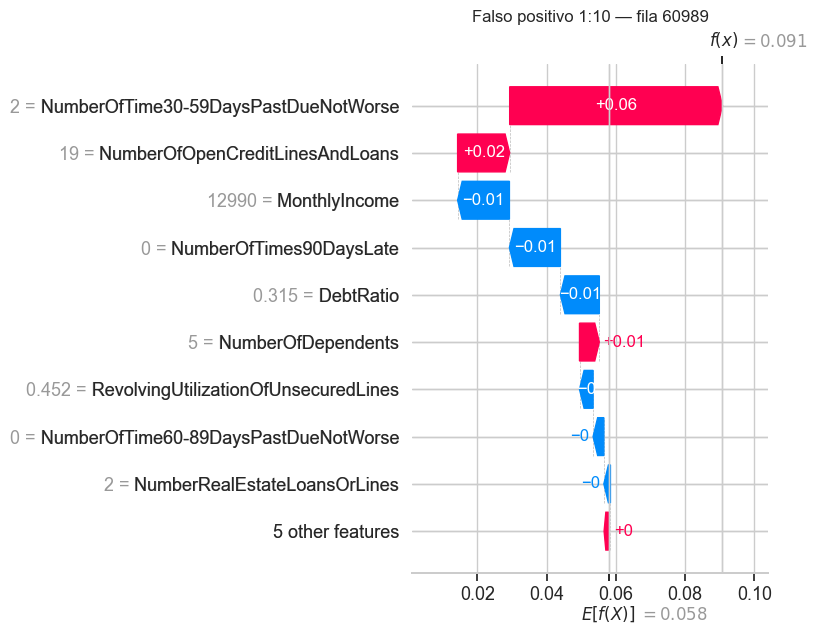

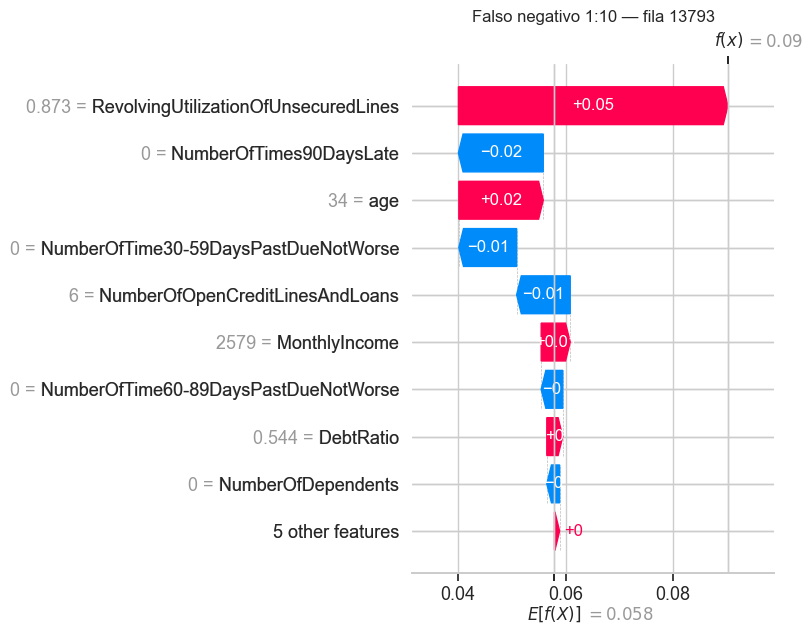

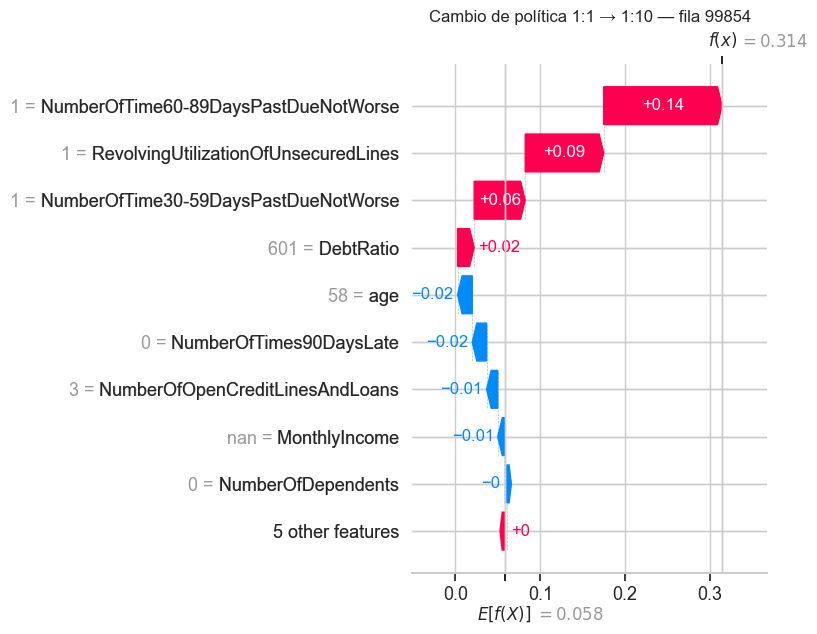

In [14]:
p_test_evaluacion_local = pd.Series(
    p_test_evaluacion, index=indices_test, name="Probabilidad"
)
y_test_evaluacion_local = y_completo.loc[indices_test]
pred_11_evaluacion_local = pd.Series(
    pred_test_11_evaluacion, index=indices_test
)
pred_110_evaluacion_local = pd.Series(
    pred_test_110_evaluacion, index=indices_test
)

# Esta serie pertenece al modelo final y se reserva para los contrafactuales
# del apartado 15; no interviene en la auditoría local fuera de muestra.
p_test_final_serie = pd.Series(
    p_test, index=indices_test, name="Probabilidad modelo final"
)

background_shap_evaluacion = X_trainval.sample(
    n=100, random_state=RANDOM_STATE
)
explicador_shap_evaluacion = shap.TreeExplainer(
    modelo_evaluacion,
    data=background_shap_evaluacion,
    feature_perturbation="interventional",
    model_output="probability",
)

usados = set()

def escoger_caso(mascara, referencia):
    candidatos = p_test_evaluacion_local.index[mascara]
    candidatos = [i for i in candidatos if i not in usados]
    assert candidatos, "No hay candidatos para una categoría SHAP local."
    elegido = min(
        candidatos,
        key=lambda i: abs(p_test_evaluacion_local.loc[i] - referencia),
    )
    usados.add(elegido)
    return elegido


especificaciones = [
    (
        "Verdadero negativo 1:10",
        (y_test_evaluacion_local == 0)
        & (pred_110_evaluacion_local == 0),
        umbral_110_evaluacion,
    ),
    (
        "Verdadero positivo 1:10",
        (y_test_evaluacion_local == 1)
        & (pred_110_evaluacion_local == 1),
        umbral_110_evaluacion,
    ),
    (
        "Falso positivo 1:10",
        (y_test_evaluacion_local == 0)
        & (pred_110_evaluacion_local == 1),
        umbral_110_evaluacion,
    ),
    (
        "Falso negativo 1:10",
        (y_test_evaluacion_local == 1)
        & (pred_110_evaluacion_local == 0),
        umbral_110_evaluacion,
    ),
    (
        "Cambio de política 1:1 → 1:10",
        (p_test_evaluacion_local >= umbral_110_evaluacion)
        & (p_test_evaluacion_local < umbral_11_evaluacion),
        (umbral_110_evaluacion + umbral_11_evaluacion) / 2,
    ),
]

casos_locales = []
for etiqueta, mascara, referencia in especificaciones:
    indice = escoger_caso(mascara, referencia)
    casos_locales.append((etiqueta, indice))

indices_locales = [indice for _, indice in casos_locales]
X_shap_local = X_test.loc[indices_locales]
valores_shap_local = explicador_shap_evaluacion(
    X_shap_local, check_additivity=False
)
reconstruccion_shap_local = (
    np.asarray(valores_shap_local.base_values)
    + valores_shap_local.values.sum(axis=1)
)
error_aditividad_shap_local = float(
    np.max(
        np.abs(
            reconstruccion_shap_local
            - modelo_evaluacion.predict_proba(X_shap_local)[:, 1]
        )
    )
)
assert error_aditividad_shap_local < 1e-5

tabla_casos_locales = []
contribuciones_locales = []
for posicion, (etiqueta, indice) in enumerate(casos_locales):
    valores = valores_shap_local.values[posicion]
    orden = np.argsort(np.abs(valores))[::-1][:3]
    tabla_casos_locales.append(
        {
            "Caso": etiqueta,
            "Índice original": indice,
            "Clase real": int(y_completo.loc[indice]),
            "Probabilidad": p_test_evaluacion_local.loc[indice],
            "Umbral 1:10": umbral_110_evaluacion,
            "Predicción 1:1": int(
                pred_11_evaluacion_local.loc[indice]
            ),
            "Predicción 1:10": int(
                pred_110_evaluacion_local.loc[indice]
            ),
        }
    )
    for j in orden:
        contribuciones_locales.append(
            {
                "Caso": etiqueta,
                "Variable": X_shap_local.columns[j],
                "Valor": X_shap_local.iloc[posicion, j],
                "SHAP": valores[j],
                "Dirección": "sube riesgo" if valores[j] > 0 else "baja riesgo",
            }
        )

tabla_casos_locales = pd.DataFrame(tabla_casos_locales)
contribuciones_locales = pd.DataFrame(contribuciones_locales)
display(tabla_casos_locales)
display(contribuciones_locales)

for posicion, (etiqueta, indice) in enumerate(casos_locales):
    shap.plots.waterfall(
        valores_shap_local[posicion], max_display=10, show=False
    )
    plt.title(f"{etiqueta} — fila {indice}")
    plt.tight_layout()
    plt.show()

**Lectura de los casos fuera de muestra.** Los TP, FP, TN y FN anteriores pertenecen al
modelo de evaluación y, por tanto, sí permiten analizar aciertos y errores sin contaminación
del test. Deben comunicarse los factores que más suben y bajan la puntuación, la
probabilidad y el umbral aplicado, sin presentar ninguna contribución SHAP como causa real.
La diferencia entre 1:1 y 1:10 procede del coste y del umbral, no de un cambio de modelo.

## 13. Modelo subrogado global y reglas

Un árbol de regresión pequeño intenta imitar la probabilidad del LightGBM. Se separa una
muestra para ajustar el subrogado y otra para elegir el número de hojas. La fidelidad final
se mide en el test que el subrogado no ha visto.

Se comparan 3, 5, 8 y 12 hojas. Se elige el árbol más pequeño cuya R² quede a menos de 0,03
del mejor candidato. Además de R² y MAE, se mide el acuerdo de decisiones en ambos umbrales.

,Hojas,R² validación subrogado,MAE validación subrogado,Acuerdo 1:1,Acuerdo 1:10
0,3,0.6135,0.0397,0.9811,0.8759
1,5,0.7205,0.0348,0.9846,0.8759
2,8,0.7942,0.0296,0.9846,0.8851
3,12,0.8407,0.0249,0.9846,0.9178


,Fidelidad
Hojas elegidas,12.0000
R² en test,0.8297
MAE en test,0.0261
Acuerdo 1:1,0.9852
Acuerdo equilibrado 1:1,0.8013
Acuerdo 1:10,0.9112
Acuerdo equilibrado 1:10,0.7921


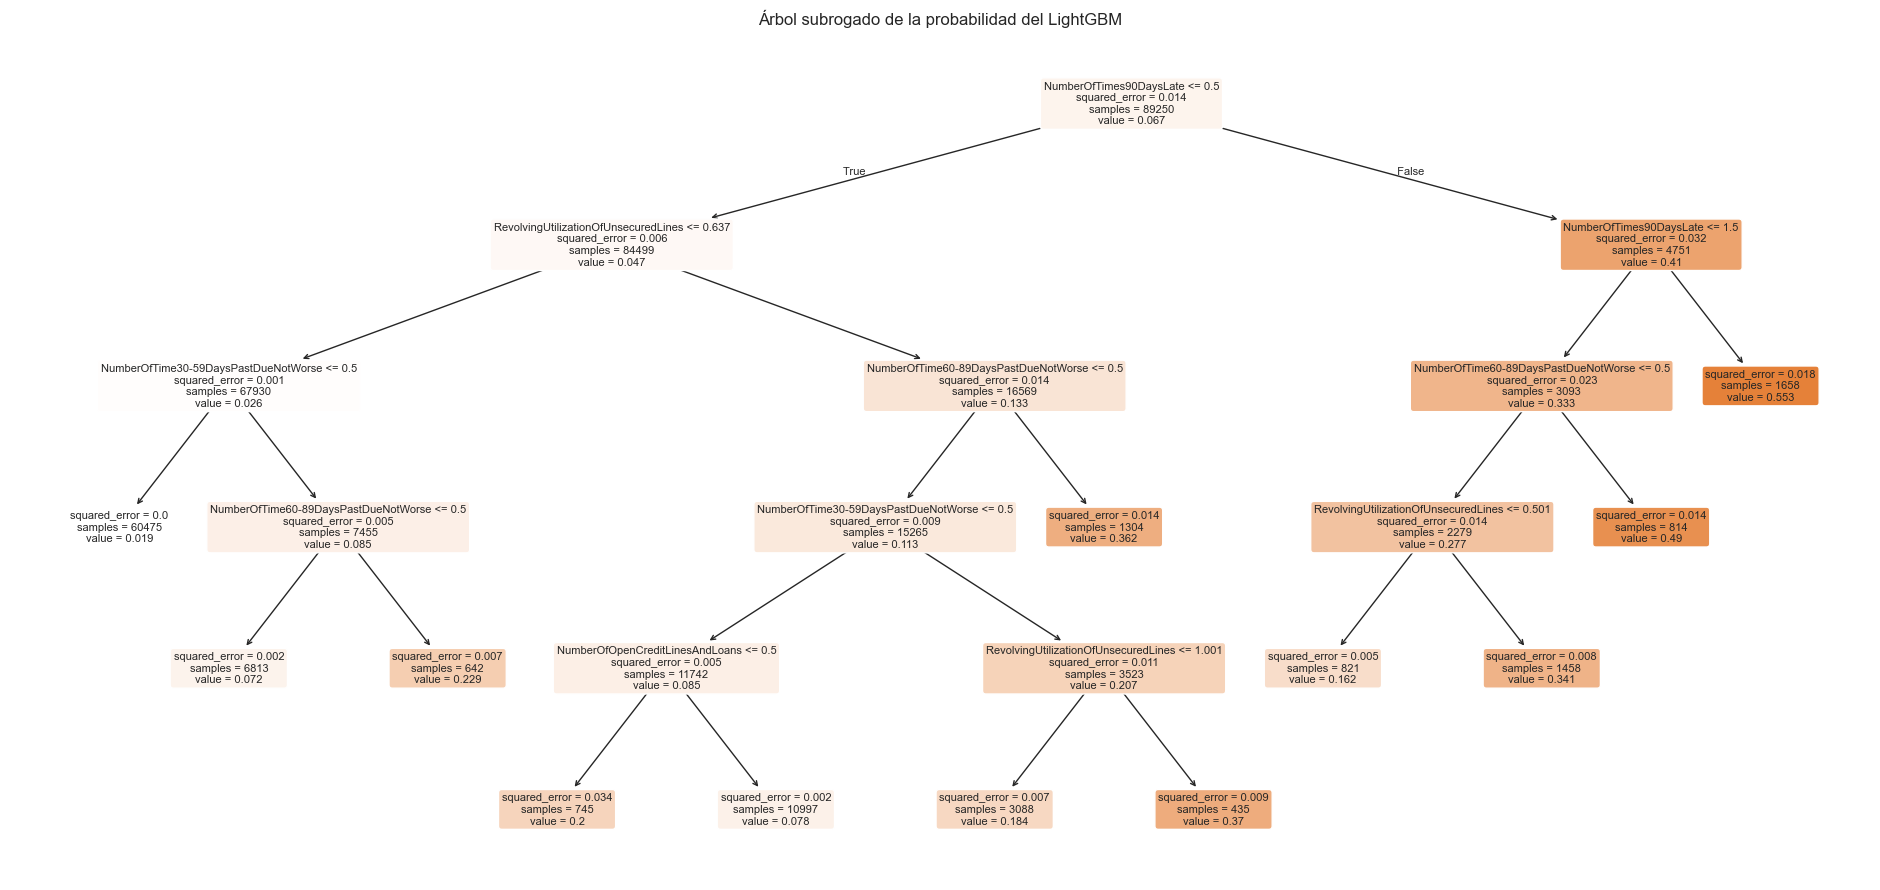

|--- NumberOfTimes90DaysLate <= 0.500
|   |--- RevolvingUtilizationOfUnsecuredLines <= 0.637
|   |   |--- NumberOfTime30-59DaysPastDueNotWorse <= 0.500
|   |   |   |--- value: [0.019]
|   |   |--- NumberOfTime30-59DaysPastDueNotWorse >  0.500
|   |   |   |--- NumberOfTime60-89DaysPastDueNotWorse <= 0.500
|   |   |   |   |--- value: [0.072]
|   |   |   |--- NumberOfTime60-89DaysPastDueNotWorse >  0.500
|   |   |   |   |--- value: [0.229]
|   |--- RevolvingUtilizationOfUnsecuredLines >  0.637
|   |   |--- NumberOfTime60-89DaysPastDueNotWorse <= 0.500
|   |   |   |--- NumberOfTime30-59DaysPastDueNotWorse <= 0.500
|   |   |   |   |--- NumberOfOpenCreditLinesAndLoans <= 0.500
|   |   |   |   |   |--- value: [0.200]
|   |   |   |   |--- NumberOfOpenCreditLinesAndLoans >  0.500
|   |   |   |   |   |--- value: [0.078]
|   |   |   |--- NumberOfTime30-59DaysPastDueNotWorse >  0.500
|   |   |   |   |--- RevolvingUtilizationOfUnsecuredLines <= 1.001
|   |   |   |   |   |--- value: [0.184]
|   |   

In [15]:
indices_sub_fit, indices_sub_val = train_test_split(
    indices_trainval,
    test_size=0.20,
    random_state=RANDOM_STATE,
)
X_sub_fit = X_trainval.loc[indices_sub_fit]
X_sub_val = X_trainval.loc[indices_sub_val]
p_black_fit = modelo_final.predict_proba(X_sub_fit)[:, 1]
p_black_val = modelo_final.predict_proba(X_sub_val)[:, 1]

candidatos_subrogado = {}
filas_fidelidad = []
for hojas in [3, 5, 8, 12]:
    subrogado = Pipeline(
        [
            ("imputación", SimpleImputer(strategy="median")),
            (
                "árbol",
                DecisionTreeRegressor(
                    max_leaf_nodes=hojas,
                    min_samples_leaf=300,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )
    subrogado.fit(X_sub_fit, p_black_fit)
    p_sub_val = subrogado.predict(X_sub_val)
    filas_fidelidad.append(
        {
            "Hojas": hojas,
            "R² validación subrogado": r2_score(p_black_val, p_sub_val),
            "MAE validación subrogado": mean_absolute_error(
                p_black_val, p_sub_val
            ),
            "Acuerdo 1:1": accuracy_score(
                p_black_val >= umbral_11, p_sub_val >= umbral_11
            ),
            "Acuerdo 1:10": accuracy_score(
                p_black_val >= umbral_110, p_sub_val >= umbral_110
            ),
        }
    )
    candidatos_subrogado[hojas] = subrogado

comparacion_subrogado = pd.DataFrame(filas_fidelidad)
r2_maximo = comparacion_subrogado["R² validación subrogado"].max()
hojas_elegidas = int(
    comparacion_subrogado.loc[
        comparacion_subrogado["R² validación subrogado"] >= r2_maximo - 0.03,
        "Hojas",
    ].min()
)

subrogado_final = Pipeline(
    [
        ("imputación", SimpleImputer(strategy="median")),
        (
            "árbol",
            DecisionTreeRegressor(
                max_leaf_nodes=hojas_elegidas,
                min_samples_leaf=300,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
p_black_trainval = modelo_final.predict_proba(X_trainval)[:, 1]
subrogado_final.fit(X_trainval, p_black_trainval)
p_sub_test = subrogado_final.predict(X_test)

fidelidad_test = pd.Series(
    {
        "Hojas elegidas": hojas_elegidas,
        "R² en test": r2_score(p_test, p_sub_test),
        "MAE en test": mean_absolute_error(p_test, p_sub_test),
        "Acuerdo 1:1": accuracy_score(
            p_test >= umbral_11, p_sub_test >= umbral_11
        ),
        "Acuerdo equilibrado 1:1": balanced_accuracy_score(
            p_test >= umbral_11, p_sub_test >= umbral_11
        ),
        "Acuerdo 1:10": accuracy_score(
            p_test >= umbral_110, p_sub_test >= umbral_110
        ),
        "Acuerdo equilibrado 1:10": balanced_accuracy_score(
            p_test >= umbral_110, p_sub_test >= umbral_110
        ),
    },
    name="Fidelidad",
).to_frame()

display(comparacion_subrogado)
display(fidelidad_test)

arbol_subrogado = subrogado_final.named_steps["árbol"]
plt.figure(figsize=(24, 11))
plot_tree(
    arbol_subrogado,
    feature_names=X_trainval.columns,
    filled=True,
    rounded=True,
    precision=3,
    fontsize=8,
)
plt.title("Árbol subrogado de la probabilidad del LightGBM")
plt.show()

reglas_subrogado = export_text(
    arbol_subrogado,
    feature_names=list(X_trainval.columns),
    decimals=3,
)
print(reglas_subrogado)

La fidelidad mide cuánto se parece el árbol al modelo, no cuánto predice la realidad. El
acuerdo equilibrado evita que una réplica que siempre diga clase 0 parezca excelente por
el desbalance. La siguiente celda resume el compromiso real obtenido.

In [16]:
display(
    Markdown(
        f'''
        **Resultado del subrogado.** Se eligen **{hojas_elegidas} hojas**. En test alcanza
        R² **{fidelidad_test.loc['R² en test', 'Fidelidad']:.3f}** y MAE
        **{fidelidad_test.loc['MAE en test', 'Fidelidad']:.4f}**. El acuerdo de decisión
        es **{100 * fidelidad_test.loc['Acuerdo 1:1', 'Fidelidad']:.2f} %** en 1:1 y
        **{100 * fidelidad_test.loc['Acuerdo 1:10', 'Fidelidad']:.2f} %** en 1:10.
        Las reglas son un resumen útil, pero no sustituyen al LightGBM.
        '''
    )
)


        **Resultado del subrogado.** Se eligen **12 hojas**. En test alcanza
        R² **0.830** y MAE
        **0.0261**. El acuerdo de decisión
        es **98.52 %** en 1:1 y
        **91.12 %** en 1:10.
        Las reglas son un resumen útil, pero no sustituyen al LightGBM.
        

## 14. Importancia por permutación orientada a coste

Como comprobación independiente de SHAP se permuta cada variable del test sobre el modelo de evaluación fuera de muestra y se observa
cuánto aumenta el coste 1:10 usando el umbral ya fijado. El umbral no se reoptimiza después
de permutar. Una subida grande indica que romper esa información perjudica la política.

Las variables derivadas y correlacionadas pueden repartirse la importancia; por ello esta
técnica se interpreta junto con SHAP, no como una verdad única.

,Variable,Aumento medio de coste,Desviación
0,RevolvingUtilizationOfUnsecuredLines,0.0707,0.0017
1,NumberOfTimes90DaysLate,0.0562,0.0013
2,NumberOfTime30-59DaysPastDueNotWorse,0.0465,0.0007
3,NumberOfTime60-89DaysPastDueNotWorse,0.0344,0.0023
4,age,0.0161,0.0022
5,NumberOfOpenCreditLinesAndLoans,0.0153,0.0014
6,DebtRatio,0.0140,0.0022
7,NumberRealEstateLoansOrLines,0.0067,0.0036
8,MonthlyIncome,0.0064,0.0017
9,NumberOfDependents,0.0018,0.0009


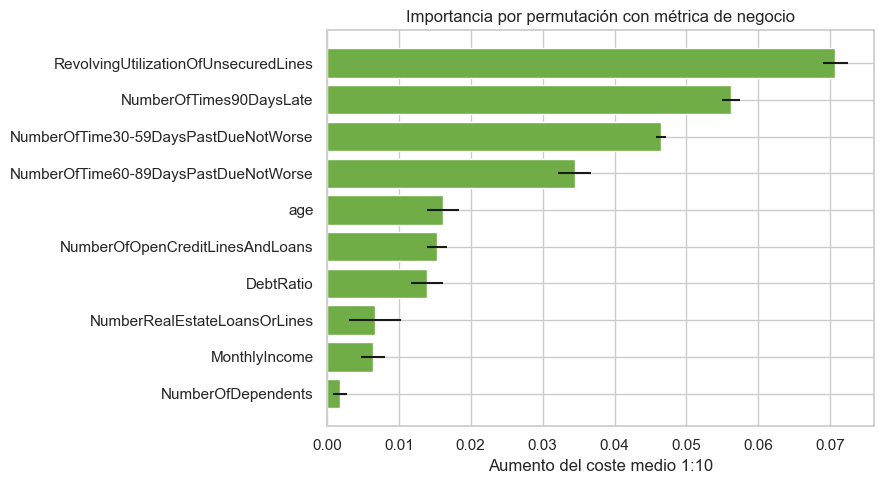

In [17]:
rng = np.random.default_rng(RANDOM_STATE)
coste_base_permutacion = coste_medio(
    y_test, p_test_evaluacion >= umbral_110_evaluacion, coste_fp=1, coste_fn=10
)
filas_permutacion = []

for columna in X_test.columns:
    incrementos = []
    for _ in range(4):
        X_permutado = X_test.copy()
        X_permutado[columna] = rng.permutation(
            X_permutado[columna].to_numpy()
        )
        p_permutado = modelo_evaluacion.predict_proba(X_permutado)[:, 1]
        coste_permutado = coste_medio(
            y_test,
            p_permutado >= umbral_110_evaluacion,
            coste_fp=1,
            coste_fn=10,
        )
        incrementos.append(coste_permutado - coste_base_permutacion)
    filas_permutacion.append(
        {
            "Variable": columna,
            "Aumento medio de coste": np.mean(incrementos),
            "Desviación": np.std(incrementos),
        }
    )

importancia_permutacion = (
    pd.DataFrame(filas_permutacion)
    .sort_values("Aumento medio de coste", ascending=False)
    .reset_index(drop=True)
)
display(importancia_permutacion)

top_perm = importancia_permutacion.head(10).sort_values(
    "Aumento medio de coste"
)
plt.figure(figsize=(9, 5))
plt.barh(
    top_perm["Variable"],
    top_perm["Aumento medio de coste"],
    xerr=top_perm["Desviación"],
    color="#70AD47",
)
plt.xlabel("Aumento del coste medio 1:10")
plt.title("Importancia por permutación con métrica de negocio")
plt.tight_layout()
plt.show()

## 15. Contrafactuales restringidos y comunicación al cliente

Se estudia la política 1:10, que deniega o revisa más solicitudes. Para dos casos reales de
cada clase se buscan cambios que reduzcan la probabilidad por debajo del umbral.

Las variables históricas o inmutables permanecen bloqueadas: edad, dependientes y moras
pasadas no se modifican. Solo se permiten movimientos con dirección de mejora plausible:
reducir utilización y ratio de deuda, documentar o aumentar ingresos y reducir líneas
abiertas. Los valores candidatos proceden de cuantiles observados o cambios graduales.
La distancia usa el rango intercuartílico para comparar escalas. Finalmente se construye
para cada caso una comunicación en lenguaje natural basada en el modelo final: incluye la
probabilidad, el umbral, los principales factores SHAP, un escenario alternativo y el derecho
a solicitar revisión humana o corrección de datos. La clase real se omite deliberadamente
porque no estaría disponible en el momento de comunicar una decisión.

In [18]:
variables_accionables = [
    "RevolvingUtilizationOfUnsecuredLines",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans",
]
cuantiles_accionables = {
    columna: X_train_raw[columna]
    .quantile([0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95])
    .to_dict()
    for columna in variables_accionables
}
iqr_accionables = {
    columna: max(
        X_train_raw[columna].quantile(0.75)
        - X_train_raw[columna].quantile(0.25),
        1e-6,
    )
    for columna in variables_accionables
}

def valores_unicos(valores):
    resultado = []
    for valor in valores:
        if pd.isna(valor):
            continue
        valor = float(valor)
        if not any(np.isclose(valor, previo) for previo in resultado):
            resultado.append(valor)
    return resultado


def rejilla_accionable(fila):
    utilizacion = float(fila["RevolvingUtilizationOfUnsecuredLines"])
    deuda = float(fila["DebtRatio"])
    ingreso = fila["MonthlyIncome"]
    lineas = float(fila["NumberOfOpenCreditLinesAndLoans"])

    valores_utilizacion = valores_unicos(
        [
            utilizacion,
            0.90 * utilizacion,
            0.75 * utilizacion,
            0.50 * utilizacion,
            0.25 * utilizacion,
            cuantiles_accionables[
                "RevolvingUtilizationOfUnsecuredLines"
            ][0.25],
            cuantiles_accionables[
                "RevolvingUtilizationOfUnsecuredLines"
            ][0.10],
            cuantiles_accionables[
                "RevolvingUtilizationOfUnsecuredLines"
            ][0.05],
        ]
    )
    valores_utilizacion = [
        v for v in valores_utilizacion if 0 <= v <= utilizacion
    ]

    valores_deuda = valores_unicos(
        [
            deuda,
            0.90 * deuda,
            0.75 * deuda,
            0.50 * deuda,
            0.25 * deuda,
            cuantiles_accionables["DebtRatio"][0.25],
            cuantiles_accionables["DebtRatio"][0.10],
            cuantiles_accionables["DebtRatio"][0.05],
        ]
    )
    valores_deuda = [v for v in valores_deuda if 0 <= v <= deuda]

    limite_ingreso = cuantiles_accionables["MonthlyIncome"][0.95]
    if pd.isna(ingreso):
        valores_ingreso = valores_unicos(
            [
                cuantiles_accionables["MonthlyIncome"][0.50],
                cuantiles_accionables["MonthlyIncome"][0.75],
                cuantiles_accionables["MonthlyIncome"][0.90],
            ]
        )
    else:
        ingreso = float(ingreso)
        valores_ingreso = valores_unicos(
            [
                ingreso,
                min(1.10 * ingreso, limite_ingreso),
                min(1.25 * ingreso, limite_ingreso),
                min(1.50 * ingreso, limite_ingreso),
                min(2.00 * ingreso, limite_ingreso),
                cuantiles_accionables["MonthlyIncome"][0.75],
                cuantiles_accionables["MonthlyIncome"][0.90],
                limite_ingreso,
            ]
        )
        valores_ingreso = [v for v in valores_ingreso if v >= ingreso]

    valores_lineas = valores_unicos(
        [
            lineas,
            max(0, lineas - 1),
            max(0, lineas - 2),
            max(0, lineas - 4),
            cuantiles_accionables["NumberOfOpenCreditLinesAndLoans"][0.25],
            cuantiles_accionables["NumberOfOpenCreditLinesAndLoans"][0.10],
        ]
    )
    valores_lineas = [
        int(round(v)) for v in valores_lineas if v <= lineas
    ]
    valores_lineas = list(dict.fromkeys(valores_lineas))

    return (
        valores_utilizacion,
        valores_deuda,
        valores_ingreso,
        valores_lineas,
    )


def buscar_contrafactual(fila_raw, umbral):
    rejilla = rejilla_accionable(fila_raw)
    candidatos = []
    for valores in itertools.product(*rejilla):
        candidato = fila_raw.copy()
        for columna, valor in zip(variables_accionables, valores):
            candidato[columna] = valor
        candidatos.append(candidato)

    candidatos = pd.DataFrame(candidatos)
    p_candidatos = modelo_final.predict_proba(
        preparar_variables(candidatos)
    )[:, 1]
    posiciones_validas = np.flatnonzero(p_candidatos < umbral)
    if len(posiciones_validas) == 0:
        return None

    distancias = []
    for posicion in posiciones_validas:
        candidato = candidatos.iloc[posicion]
        distancia = 0.0
        cambios = 0
        for columna in variables_accionables:
            original = fila_raw[columna]
            nuevo = candidato[columna]
            if pd.isna(original):
                distancia += 0.5
                cambios += 1
            else:
                distancia += abs(nuevo - original) / iqr_accionables[columna]
                cambios += int(not np.isclose(nuevo, original))
        distancias.append(distancia + 0.05 * cambios)

    mejor_local = int(np.argmin(distancias))
    mejor_posicion = int(posiciones_validas[mejor_local])
    mejor = candidatos.iloc[mejor_posicion]

    assert (
        mejor["RevolvingUtilizationOfUnsecuredLines"]
        <= fila_raw["RevolvingUtilizationOfUnsecuredLines"]
    )
    assert mejor["DebtRatio"] <= fila_raw["DebtRatio"]
    if pd.notna(fila_raw["MonthlyIncome"]):
        assert mejor["MonthlyIncome"] >= fila_raw["MonthlyIncome"]
    assert (
        mejor["NumberOfOpenCreditLinesAndLoans"]
        <= fila_raw["NumberOfOpenCreditLinesAndLoans"]
    )
    for columna in set(variables_originales) - set(variables_accionables):
        a, b = fila_raw[columna], mejor[columna]
        assert (pd.isna(a) and pd.isna(b)) or np.isclose(a, b)

    return {
        "fila": mejor,
        "probabilidad": float(p_candidatos[mejor_posicion]),
        "distancia": float(distancias[mejor_local]),
    }


def describir_cambios(original, nuevo):
    etiquetas = {
        "RevolvingUtilizationOfUnsecuredLines": "utilización",
        "DebtRatio": "ratio de deuda",
        "MonthlyIncome": "ingreso mensual",
        "NumberOfOpenCreditLinesAndLoans": "líneas abiertas",
    }
    cambios = []
    for columna in variables_accionables:
        antes, despues = original[columna], nuevo[columna]
        cambio = pd.isna(antes) or not np.isclose(antes, despues)
        if cambio:
            antes_txt = "ausente" if pd.isna(antes) else f"{antes:.3f}"
            despues_txt = f"{despues:.3f}"
            cambios.append(f"{etiquetas[columna]}: {antes_txt} → {despues_txt}")
    return "; ".join(cambios)


resultados_contrafactuales = []
detalles_contrafactuales = {}
usados_cf = set()

for clase_real in [0, 1]:
    candidatos_clase = [
        i
        for i in indices_test
        if y_completo.loc[i] == clase_real
        and p_test_final_serie.loc[i] >= umbral_110
    ]
    candidatos_clase = sorted(
        candidatos_clase, key=lambda i: p_test_final_serie.loc[i]
    )

    for fraccion in [0.25, 0.50]:
        centro = int(fraccion * (len(candidatos_clase) - 1))
        encontrado = None
        orden_busqueda = [0]
        for desplazamiento in range(1, 151):
            orden_busqueda.extend([-desplazamiento, desplazamiento])

        for desplazamiento in orden_busqueda:
            posicion = centro + desplazamiento
            if not 0 <= posicion < len(candidatos_clase):
                continue
            indice = candidatos_clase[posicion]
            if indice in usados_cf:
                continue
            resultado = buscar_contrafactual(
                X_original.loc[indice], umbral_110
            )
            if resultado is not None:
                encontrado = (indice, resultado)
                usados_cf.add(indice)
                break

        assert encontrado is not None, (
            f"No se encontró contrafactual para clase {clase_real} "
            f"y fracción {fraccion}."
        )
        indice, resultado = encontrado
        detalles_contrafactuales[indice] = resultado
        resultados_contrafactuales.append(
            {
                "Índice": indice,
                "Clase real": clase_real,
                "Percentil aproximado entre denegados": fraccion,
                "Probabilidad original": p_test_final_serie.loc[indice],
                "Probabilidad contrafactual": resultado["probabilidad"],
                "Umbral 1:10": umbral_110,
                "Distancia normalizada": resultado["distancia"],
                "Cambios propuestos": describir_cambios(
                    X_original.loc[indice], resultado["fila"]
                ),
            }
        )

tabla_contrafactuales = pd.DataFrame(resultados_contrafactuales)
assert len(tabla_contrafactuales) == 4
assert (
    tabla_contrafactuales["Probabilidad contrafactual"] < umbral_110
).all()
assert set(tabla_contrafactuales["Clase real"]) == {0, 1}
display(tabla_contrafactuales)

def unir_natural(elementos):
    if not elementos:
        return "los datos del expediente en su conjunto"
    if len(elementos) == 1:
        return elementos[0]
    return ", ".join(elementos[:-1]) + " y " + elementos[-1]


def numero_es(valor):
    return f"{valor:,.0f}".replace(",", ".")


def describir_factor_cliente(variable, fila):
    valor = fila[variable]
    if variable == "RevolvingUtilizationOfUnsecuredLines":
        return f"el nivel de uso del crédito disponible ({100 * valor:.1f} %)"
    if variable == "DebtRatio":
        if valor <= 10:
            return (
                "la proporción mensual destinada a deuda "
                f"({100 * valor:.1f} %)"
            )
        return (
            f"el indicador de endeudamiento registrado ({numero_es(valor)}), "
            "que debe revisarse junto con los ingresos declarados"
        )
    if variable == "MonthlyIncome":
        return (
            "la ausencia de ingresos mensuales declarados"
            if pd.isna(valor)
            else f"los ingresos mensuales declarados ({numero_es(valor)})"
        )
    if variable == "NumberOfOpenCreditLinesAndLoans":
        return f"el número de préstamos y líneas de crédito abiertos ({valor:.0f})"
    if variable == "NumberRealEstateLoansOrLines":
        return f"el número de préstamos o líneas inmobiliarias ({valor:.0f})"
    if variable == "NumberOfTime30-59DaysPastDueNotWorse":
        return f"los retrasos de 30 a 59 días registrados ({valor:.0f})"
    if variable == "NumberOfTime60-89DaysPastDueNotWorse":
        return f"los retrasos de 60 a 89 días registrados ({valor:.0f})"
    if variable == "NumberOfTimes90DaysLate":
        return f"los retrasos de 90 días o más registrados ({valor:.0f})"
    if variable == "age":
        return f"la edad registrada ({valor:.0f} años)"
    if variable == "NumberOfDependents":
        return (
            "la ausencia del número de personas dependientes"
            if pd.isna(valor)
            else f"el número de personas dependientes ({valor:.0f})"
        )
    if variable == "MonthlyIncome_missing":
        return (
            "la ausencia de ingresos mensuales declarados"
            if valor == 1
            else "que los ingresos mensuales sí constan"
        )
    if variable == "NumberOfDependents_missing":
        return (
            "la ausencia del número de personas dependientes"
            if valor == 1
            else "que el número de personas dependientes sí consta"
        )
    if variable == "DelinquencySentinel96_98":
        return (
            "un valor anómalo registrado en el historial de retrasos"
            if valor == 1
            else "el patrón registrado en el historial de retrasos"
        )
    if variable == "age_invalid":
        return (
            "un valor de edad ausente o fuera del rango esperado"
            if valor == 1
            else "el valor de edad registrado"
        )
    return variable


def describir_cambios_cliente(original, nuevo):
    cambios = []
    for columna in variables_accionables:
        antes, despues = original[columna], nuevo[columna]
        if pd.notna(antes) and np.isclose(antes, despues):
            continue
        if columna == "RevolvingUtilizationOfUnsecuredLines":
            cambios.append(
                f"el uso del crédito disponible pasara de "
                f"{100 * antes:.1f} % a {100 * despues:.1f} %"
            )
        elif columna == "DebtRatio":
            if max(antes, despues) <= 10:
                cambios.append(
                    f"la proporción mensual destinada a deuda pasara de "
                    f"{100 * antes:.1f} % a {100 * despues:.1f} %"
                )
            else:
                cambios.append(
                    f"el indicador de endeudamiento registrado pasara de "
                    f"{numero_es(antes)} a {numero_es(despues)}"
                )
        elif columna == "MonthlyIncome":
            if pd.isna(antes):
                cambios.append(
                    "se aportara documentación de ingresos mensuales "
                    f"y el escenario simulado registrara {numero_es(despues)}"
                )
            else:
                cambios.append(
                    f"los ingresos mensuales declarados pasaran de "
                    f"{numero_es(antes)} a {numero_es(despues)}"
                )
        else:
            cambios.append(
                f"los préstamos y líneas de crédito abiertos pasaran de "
                f"{antes:.0f} a {despues:.0f}"
            )
    return cambios


indices_cf = tabla_contrafactuales["Índice"].tolist()
X_cf_cliente = preparar_variables(X_original.loc[indices_cf])
shap_cf_cliente = explicador_shap(
    X_cf_cliente, check_additivity=False
)
claves_semanticas = {
    "MonthlyIncome_missing": "MonthlyIncome",
    "NumberOfDependents_missing": "NumberOfDependents",
    "DelinquencySentinel96_98": "historial_retrasos",
    "NumberOfTime30-59DaysPastDueNotWorse": "mora_30_59",
    "NumberOfTime60-89DaysPastDueNotWorse": "mora_60_89",
    "NumberOfTimes90DaysLate": "mora_90",
    "age_invalid": "age",
}

mensajes_clientes = []
for posicion, indice in enumerate(indices_cf):
    contribuciones = shap_cf_cliente.values[posicion]
    orden = np.argsort(contribuciones)[::-1]
    factores, conceptos_usados = [], set()
    for j in orden:
        if contribuciones[j] <= 0:
            break
        variable = X_cf_cliente.columns[j]
        concepto = claves_semanticas.get(variable, variable)
        if concepto in conceptos_usados:
            continue
        factores.append(
            describir_factor_cliente(
                variable, X_cf_cliente.iloc[posicion]
            )
        )
        conceptos_usados.add(concepto)
        if len(factores) == 3:
            break

    original = X_original.loc[indice]
    contrafactual = detalles_contrafactuales[indice]
    cambios = describir_cambios_cliente(
        original, contrafactual["fila"]
    )
    p_original = float(p_test_final_serie.loc[indice])
    p_simulada = contrafactual["probabilidad"]

    mensajes_clientes.append(
        f'''
### Comunicación ilustrativa — solicitud {indice}

Su solicitud ha sido denegada bajo la política 1:10 porque el modelo estimó una
probabilidad de mora grave de **{p_original:.1%}**, superior al umbral aplicado de
**{umbral_110:.1%}**. Los datos que más elevaron la puntuación fueron
**{unir_natural(factores)}**.

Como orientación, una simulación del propio modelo reduce la probabilidad a
**{p_simulada:.1%}** si {unir_natural(cambios)}. Este escenario sirve para entender la
decisión del modelo: **no demuestra que esos factores causen una mora ni garantiza que
realizar esos cambios produzca una aprobación**.

Puede solicitar una **revisión humana** de la decisión y pedir la **corrección de datos
incompletos o incorrectos** utilizados en la evaluación.
'''
    )

display(Markdown("\n\n---\n\n".join(mensajes_clientes)))

,Índice,Clase real,Percentil aproximado entre denegados,Probabilidad original,Probabilidad contrafactual,Umbral 1:10,Distancia normalizada,Cambios propuestos
0,22668,0,0.2500,0.1053,0.0777,0.0815,1.3286,utilización: 0.013 → 0.006; ingreso mensual: ausente → 11666.000; líneas abiertas: 18.000 → 14.000
1,90199,0,0.5000,0.1508,0.0771,0.0815,2.0197,utilización: 1.000 → 0.250; ingreso mensual: ausente → 11666.000
2,4763,1,0.2500,0.1736,0.0646,0.0815,1.4697,utilización: 1.000 → 0.250
3,93430,1,0.5000,0.3296,0.0781,0.0815,2.2795,utilización: 1.005 → 0.030; líneas abiertas: 5.000 → 3.000



### Comunicación ilustrativa — solicitud 22668

Su solicitud ha sido denegada bajo la política 1:10 porque el modelo estimó una
probabilidad de mora grave de **10.5%**, superior al umbral aplicado de
**8.1%**. Los datos que más elevaron la puntuación fueron
**los retrasos de 30 a 59 días registrados (1), el número de préstamos o líneas inmobiliarias (4) y el número de préstamos y líneas de crédito abiertos (18)**.

Como orientación, una simulación del propio modelo reduce la probabilidad a
**7.8%** si el uso del crédito disponible pasara de 1.3 % a 0.6 %, se aportara documentación de ingresos mensuales y el escenario simulado registrara 11.666 y los préstamos y líneas de crédito abiertos pasaran de 18 a 14. Este escenario sirve para entender la
decisión del modelo: **no demuestra que esos factores causen una mora ni garantiza que
realizar esos cambios produzca una aprobación**.

Puede solicitar una **revisión humana** de la decisión y pedir la **corrección de datos
incompletos o incorrectos** utilizados en la evaluación.


---


### Comunicación ilustrativa — solicitud 90199

Su solicitud ha sido denegada bajo la política 1:10 porque el modelo estimó una
probabilidad de mora grave de **15.1%**, superior al umbral aplicado de
**8.1%**. Los datos que más elevaron la puntuación fueron
**los retrasos de 90 días o más registrados (1), el nivel de uso del crédito disponible (100.0 %) y el indicador de endeudamiento registrado (1.535), que debe revisarse junto con los ingresos declarados**.

Como orientación, una simulación del propio modelo reduce la probabilidad a
**7.7%** si el uso del crédito disponible pasara de 100.0 % a 25.0 % y se aportara documentación de ingresos mensuales y el escenario simulado registrara 11.666. Este escenario sirve para entender la
decisión del modelo: **no demuestra que esos factores causen una mora ni garantiza que
realizar esos cambios produzca una aprobación**.

Puede solicitar una **revisión humana** de la decisión y pedir la **corrección de datos
incompletos o incorrectos** utilizados en la evaluación.


---


### Comunicación ilustrativa — solicitud 4763

Su solicitud ha sido denegada bajo la política 1:10 porque el modelo estimó una
probabilidad de mora grave de **17.4%**, superior al umbral aplicado de
**8.1%**. Los datos que más elevaron la puntuación fueron
**el nivel de uso del crédito disponible (100.0 %), los retrasos de 30 a 59 días registrados (1) y la edad registrada (39 años)**.

Como orientación, una simulación del propio modelo reduce la probabilidad a
**6.5%** si el uso del crédito disponible pasara de 100.0 % a 25.0 %. Este escenario sirve para entender la
decisión del modelo: **no demuestra que esos factores causen una mora ni garantiza que
realizar esos cambios produzca una aprobación**.

Puede solicitar una **revisión humana** de la decisión y pedir la **corrección de datos
incompletos o incorrectos** utilizados en la evaluación.


---


### Comunicación ilustrativa — solicitud 93430

Su solicitud ha sido denegada bajo la política 1:10 porque el modelo estimó una
probabilidad de mora grave de **33.0%**, superior al umbral aplicado de
**8.1%**. Los datos que más elevaron la puntuación fueron
**los retrasos de 30 a 59 días registrados (2), el nivel de uso del crédito disponible (100.5 %) y la edad registrada (38 años)**.

Como orientación, una simulación del propio modelo reduce la probabilidad a
**7.8%** si el uso del crédito disponible pasara de 100.5 % a 3.0 % y los préstamos y líneas de crédito abiertos pasaran de 5 a 3. Este escenario sirve para entender la
decisión del modelo: **no demuestra que esos factores causen una mora ni garantiza que
realizar esos cambios produzca una aprobación**.

Puede solicitar una **revisión humana** de la decisión y pedir la **corrección de datos
incompletos o incorrectos** utilizados en la evaluación.


Las comunicaciones anteriores responden de forma explícita a qué información recibiría
una persona cuya solicitud fuese denegada: decisión y política aplicadas, probabilidad y
umbral, factores principales, escenario alternativo, límites de la explicación y vía de
revisión.

Los contrafactuales son **válidos para el modelo** porque cruzan el umbral, pero no son
promesas ni recetas causales. Cuanto mayor sea la distancia o más exigentes sean los cambios,
menos útil es la orientación. Cuando el ingreso original está ausente, el cambio representa
aportar documentación real; nunca debe interpretarse como inventar o declarar un ingreso
distinto. Las moras pasadas pueden explicar la puntuación mediante SHAP, pero permanecen
bloqueadas porque no son una acción inmediata.

## 16. Auditoría de errores por segmentos

Como reflexión crítica adicional sobre las predicciones fuera de muestra del modelo de evaluación se comparan prevalencia, tasa de marcados, FPR, FNR y
coste 1:10 por grupos de edad y por ausencia de ingresos. Esto no constituye una auditoría
legal de equidad, pero permite detectar comportamientos heterogéneos que la métrica global
podría ocultar.

In [19]:
auditoria_test = X_test_raw.copy()
auditoria_test["y_real"] = y_test
auditoria_test["p_riesgo"] = p_test_evaluacion_serie
auditoria_test["pred_1_10"] = pred_test_110_evaluacion_serie
auditoria_test["Tramo de edad"] = pd.cut(
    auditoria_test["age"],
    bins=[0, 35, 50, 65, 80, np.inf],
    labels=["≤35", "36-50", "51-65", "66-80", ">80"],
)
auditoria_test["Ingreso ausente"] = np.where(
    auditoria_test["MonthlyIncome"].isna(), "Sí", "No"
)

def metricas_por_grupo(datos, columna_grupo):
    filas = []
    for grupo, bloque in datos.groupby(columna_grupo, observed=True):
        y_g = bloque["y_real"].to_numpy()
        pred_g = bloque["pred_1_10"].to_numpy()
        tn, fp, fn, tp = confusion_matrix(
            y_g, pred_g, labels=[0, 1]
        ).ravel()
        filas.append(
            {
                columna_grupo: grupo,
                "N": len(bloque),
                "% mora real": 100 * y_g.mean(),
                "% marcado riesgo": 100 * pred_g.mean(),
                "FPR": fp / (fp + tn) if fp + tn else np.nan,
                "FNR": fn / (fn + tp) if fn + tp else np.nan,
                "Coste medio 1:10": coste_medio(y_g, pred_g, 1, 10),
            }
        )
    return pd.DataFrame(filas)

auditoria_edad = metricas_por_grupo(auditoria_test, "Tramo de edad")
auditoria_ingreso = metricas_por_grupo(auditoria_test, "Ingreso ausente")
display(auditoria_edad)
display(auditoria_ingreso)

,Tramo de edad,N,% mora real,% marcado riesgo,FPR,FNR,Coste medio 1:10
0,≤35,2282,9.9474,32.1209,0.2667,0.1850,0.4242
1,36-50,5152,8.4821,25.5435,0.2070,0.2220,0.3777
2,51-65,5313,5.9289,13.2317,0.1006,0.3651,0.3111
3,66-80,2483,2.5373,6.0814,0.0496,0.5079,0.1772
4,>80,520,2.1154,5.1923,0.0413,0.4545,0.1365


,Ingreso ausente,N,% mora real,% marcado riesgo,FPR,FNR,Coste medio 1:10
0,No,12632,7.1564,19.9177,0.1596,0.2876,0.3540
1,Sí,3118,4.7787,13.2777,0.0997,0.2081,0.1944


## 17. Conclusión ejecutiva y limitaciones

El resumen siguiente se construye directamente con las salidas ejecutadas para que sus
cifras siempre coincidan con el notebook. Se separa explícitamente la **evaluación honesta
fuera de muestra** del **modelo final de producción**: comparten arquitectura, pero no el
número de árboles, los umbrales ni los datos utilizados para el ajuste final.

In [20]:
top_shap_texto = ", ".join(importancia_shap.head(4)["Variable"])
tasa_prod_11 = 100 * pred_produccion_11.mean()
tasa_prod_110 = 100 * pred_produccion_110.mean()

display(
    Markdown(
        f'''
        ### 1. Evaluación honesta fuera de muestra

        - El modelo de evaluación es un LightGBM de 15 hojas con
          **{n_estimators_evaluacion} árboles**, entrenado con train más validación.
        - Sus umbrales, fijados antes de consultar el test, son
          **{umbral_11_evaluacion:.4f}** para 1:1 y
          **{umbral_110_evaluacion:.4f}** para 1:10.
        - En el test reservado obtiene ROC-AUC **{fila_11['ROC-AUC']:.3f}** y PR-AUC
          **{fila_11['PR-AUC']:.3f}**.
        - El coste 1:1 es **{fila_11['Coste medio']:.4f}**, frente al baseline
          **{fila_11['Baseline siempre 0']:.4f}**; el coste 1:10 es
          **{fila_110['Coste medio']:.4f}**, frente a
          **{fila_110['Baseline siempre 0']:.4f}**.
        - Estas son las métricas que estiman el rendimiento fuera de muestra; no se
          atribuyen al modelo final reentrenado con todos los datos.

        ### 2. Modelo final de producción y entregables

        - El modelo final es **{nombre_modelo}**, con
          **{n_estimators_produccion} árboles**, reentrenado con las **105.000 filas**.
        - Sus umbrales OOF de producción son **{umbral_11:.4f}** y
          **{umbral_110:.4f}**. El segundo es menor porque no detectar una mora cuesta
          diez veces más.
        - Este modelo genera `cs_produccion1.csv` y `cs_produccion2.csv`. Producción
          contiene **{tasa_prod_11:.2f} %** de clase 1 en 1:1 y
          **{tasa_prod_110:.2f} %** en 1:10.
        - Las etiquetas de producción están ocultas: su coste real no puede calcularse
          en este notebook y solo lo conocerá el evaluador.
        - SHAP global identifica como factores principales: **{top_shap_texto}**.
          El subrogado de {hojas_elegidas} hojas alcanza R²
          **{fidelidad_test.loc['R² en test', 'Fidelidad']:.3f}** en su holdout de fidelidad.

        ### Limitaciones

        1. SHAP, el subrogado y los contrafactuales explican el modelo, no relaciones
           causales.
        2. Los datos históricos pueden contener sesgos y errores de medición. Edad,
           dependientes y moras pasadas requieren especial cautela comunicativa.
        3. Un contrafactual matemáticamente válido puede ser difícil o imposible de llevar
           a la práctica.
        4. El modelo debe usarse como apoyo a una política de revisión, no como única base
           para una decisión sensible sin supervisión y controles adicionales.
        '''
    )
)


        ### 1. Evaluación honesta fuera de muestra

        - El modelo de evaluación es un LightGBM de 15 hojas con
          **418 árboles**, entrenado con train más validación.
        - Sus umbrales, fijados antes de consultar el test, son
          **0.5380** para 1:1 y
          **0.0907** para 1:10.
        - En el test reservado obtiene ROC-AUC **0.872** y PR-AUC
          **0.403**.
        - El coste 1:1 es **0.0636**, frente al baseline
          **0.0669**; el coste 1:10 es
          **0.3224**, frente a
          **0.6686**.
        - Estas son las métricas que estiman el rendimiento fuera de muestra; no se
          atribuyen al modelo final reentrenado con todos los datos.

        ### 2. Modelo final de producción y entregables

        - El modelo final es **LightGBM 15 hojas + early stopping OOF**, con
          **455 árboles**, reentrenado con las **105.000 filas**.
        - Sus umbrales OOF de producción son **0.5226** y
          **0.0815**. El segundo es menor porque no detectar una mora cuesta
          diez veces más.
        - Este modelo genera `cs_produccion1.csv` y `cs_produccion2.csv`. Producción
          contiene **1.87 %** de clase 1 en 1:1 y
          **20.35 %** en 1:10.
        - Las etiquetas de producción están ocultas: su coste real no puede calcularse
          en este notebook y solo lo conocerá el evaluador.
        - SHAP global identifica como factores principales: **RevolvingUtilizationOfUnsecuredLines, NumberOfTimes90DaysLate, NumberOfTime30-59DaysPastDueNotWorse, NumberOfTime60-89DaysPastDueNotWorse**.
          El subrogado de 12 hojas alcanza R²
          **0.830** en su holdout de fidelidad.

        ### Limitaciones

        1. SHAP, el subrogado y los contrafactuales explican el modelo, no relaciones
           causales.
        2. Los datos históricos pueden contener sesgos y errores de medición. Edad,
           dependientes y moras pasadas requieren especial cautela comunicativa.
        3. Un contrafactual matemáticamente válido puede ser difícil o imposible de llevar
           a la práctica.
        4. El modelo debe usarse como apoyo a una política de revisión, no como única base
           para una decisión sensible sin supervisión y controles adicionales.
        